## Data Loading and Preparation

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np

# Read the CSV file
df = pd.read_csv('amazon best sellers products.csv', low_memory=False)

# Clean: Drop all columns except first 30 columns
df = df.iloc[:, :30]

print(df.shape)
print(df.columns)
print(df.dtypes)

(27269, 30)
Index(['additionalProperties', 'brandName', 'breadcrumbs', 'color', 'currency',
       'current_depth', 'description', 'descriptionRaw', 'features', 'gtin',
       'imageUrls', 'inStock', 'listedPrice', 'material', 'mpn', 'name',
       'new_path', 'nodeName', 'rating', 'reviewCount', 'salePrice',
       'scrapedDate', 'size', 'sku', 'style', 'url', 'variants',
       'weight_rawUnit', 'weight_unit', 'weight_value'],
      dtype='object')
additionalProperties    object
brandName               object
breadcrumbs             object
color                   object
currency                object
current_depth           object
description             object
descriptionRaw          object
features                object
gtin                    object
imageUrls               object
inStock                 object
listedPrice             object
material                object
mpn                     object
name                    object
new_path                object
nodeName          

In [3]:
# Drop unnecessary columns
df.drop(columns=['additionalProperties', 'current_depth', 'features', 'variants', 'descriptionRaw', 'mpn', 'sku', 'breadcrumbs', 'imageUrls', 'url', 'scrapedDate', 'style', 'currency', 'gtin'], axis=1, inplace=True)
print(df.columns)

Index(['brandName', 'color', 'description', 'inStock', 'listedPrice',
       'material', 'name', 'new_path', 'nodeName', 'rating', 'reviewCount',
       'salePrice', 'size', 'weight_rawUnit', 'weight_unit', 'weight_value'],
      dtype='object')


In [4]:
# Fix dtypes
numeric_columns = ['listedPrice', 'rating', 'reviewCount', 'salePrice', 'weight_value']
df[numeric_columns] = df[numeric_columns].apply(pd.to_numeric, errors='coerce')
print(df[numeric_columns].dtypes)

listedPrice     float64
rating          float64
reviewCount     float64
salePrice       float64
weight_value    float64
dtype: object


## Exploratory Data Analysis and Pre-Processing

In [5]:
# Create discount column
df['discount_per'] = (df['listedPrice'] - df['salePrice']) / df['listedPrice']

In [6]:
# Check initial summary of discounts
print(df['discount_per'].describe())

count    14681.000000
mean        -0.429740
std         29.127422
min      -3391.550000
25%          0.000000
50%          0.144458
75%          0.333611
max          0.990000
Name: discount_per, dtype: float64


count    14681.000000
mean        -0.429740
std         29.127422
min      -3391.550000
25%          0.000000
50%          0.144458
75%          0.333611
max          0.990000
Name: discount_per, dtype: float64


<Axes: >

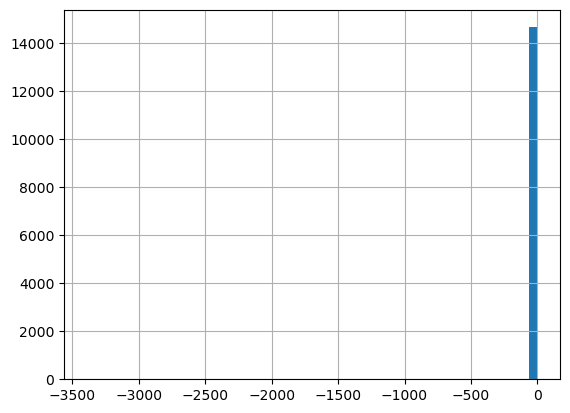

In [7]:
# Recheck summary and distribution of discounts
print(df['discount_per'].describe())
df['discount_per'].hist(bins=50)

In [8]:
# Investigate discounts that have sale price > listing price
bad_discounts = df[df['discount_per'] < 0]
print(f"Number of negative discounts: {len(bad_discounts)}")
print(bad_discounts[['listedPrice', 'salePrice', 'discount_per']].head(20))

Number of negative discounts: 937
      listedPrice  salePrice  discount_per
23          14.99      24.99     -0.667111
34          12.99      83.93     -5.461124
110         11.99      14.97     -0.248540
111         11.97      65.88     -4.503759
185         49.99     159.84     -2.197439
240         14.95      24.96     -0.669565
333         38.99      45.99     -0.179533
420          0.60       5.99     -8.983333
531          4.40      21.99     -3.997727
557         24.99      39.47     -0.579432
596          0.66       3.98     -5.030303
706         14.99      49.46     -2.299533
707         10.95     251.29    -21.948858
713         21.99      23.96     -0.089586
894          1.99      49.85    -24.050251
904         29.26      34.99     -0.195830
970         19.00      20.35     -0.071053
1003      1789.00    1799.00     -0.005590
1029        18.50      36.99     -0.999459
1143         9.39       9.99     -0.063898


In [9]:
# Before filtering, check:
print(f"Total rows: {len(df)}")
print(f"Negative discounts: {(df['discount_per'] < 0).sum()}")
print(f"Over 100% discount: {(df['discount_per'] > 1).sum()}")
print(f"NaN discount_per: {df['discount_per'].isna().sum()}")
print(f"Valid (0-1): {((df['discount_per'] >= 0) & (df['discount_per'] <= 1)).sum()}")

Total rows: 27269
Negative discounts: 937
Over 100% discount: 0
NaN discount_per: 12588
Valid (0-1): 13744


In [10]:
# Filter to keep only valid discounts (0 to 100%)
df = df[(df['discount_per'] >= 0) & (df['discount_per'] <= 1)]

# Check the results
print(f"Rows remaining: {len(df)}")
print(f"Discount depth range: {df['discount_per'].min():.2f} to {df['discount_per'].max():.2f}")

Rows remaining: 13744
Discount depth range: 0.00 to 0.99


In [11]:
# Recheck discount distribution
print(df['discount_per'].describe())

plt.figure(figsize=(10, 4))
df['discount_per'].hist(bins=50)
plt.xlabel('Discount Depth (proportion)')
plt.ylabel('Frequency')
plt.title('Distribution of Target Variable: Discount Depth')
plt.savefig('figures/discountperdistafter.png', dpi=300, bbox_inches='tight')
plt.close()

count    13744.000000
mean         0.222482
std          0.227620
min          0.000000
25%          0.000000
50%          0.166722
75%          0.350109
max          0.990000
Name: discount_per, dtype: float64


In [12]:
# Count how many have 0% discount
total = len(df)
zero_count = (df['discount_per'] == 0).sum()
print(f"0% discount: {zero_count} ({zero_count/total*100:.1f}%)")
print(f"Has discount: {total - zero_count} ({(total-zero_count)/total*100:.1f}%)")

0% discount: 3804 (27.7%)
Has discount: 9940 (72.3%)


In [13]:
# Value counts for discount_per itself
print(df['discount_per'].value_counts().head(10))

discount_per
0.000000    3804
0.230947      65
0.500250      54
0.333556      52
0.100100      50
0.166806      49
0.200200      42
0.444691      36
0.300300      31
0.100050      31
Name: count, dtype: int64


In [14]:
# Split the levels of granularity for product categories
df['category_level1'] = df['nodeName'].str.split(' > ').str[0]
df['category_level2'] = df['nodeName'].str.split(' > ').str[1]
df['category_level3'] = df['nodeName'].str.split(' > ').str[2]

In [15]:
# Check category names in each level of granularity
print(df['category_level1'].head(20))
print(df['category_level2'].head(20))
print(df['category_level3'].head(20))

1                     Pet Supplies
2             Patio, Lawn & Garden
3                     Kindle Store
4          Industrial & Scientific
5                  Office Products
6                 Kitchen & Dining
7                     Unique Finds
8              Musical Instruments
9     Amazon Devices & Accessories
16       Clothing, Shoes & Jewelry
18                     Movies & TV
19                     Movies & TV
21            Patio, Lawn & Garden
24                    Pet Supplies
25            Patio, Lawn & Garden
30            Patio, Lawn & Garden
32         Industrial & Scientific
35         Industrial & Scientific
36         Industrial & Scientific
37         Industrial & Scientific
Name: category_level1, dtype: object
1                                  NaN
2                                  NaN
3                                  NaN
4                                  NaN
5                                  NaN
6                                  NaN
7                            

In [16]:
# Check sample sizes of category granularity at each level
for level in [1, 2, 3]:
    col = f'category_level{level}'
    print(f"\nLevel {level}:")
    print(f"Number of categories: {df[col].nunique()}")
    print(f"Avg products per category: {len(df) / df[col].nunique():.0f}")
    print(f"Min products in a category: {df[col].value_counts().min()}")


Level 1:
Number of categories: 33
Avg products per category: 416
Min products in a category: 1

Level 2:
Number of categories: 307
Avg products per category: 45
Min products in a category: 1

Level 3:
Number of categories: 1648
Avg products per category: 8
Min products in a category: 1


In [17]:
# Fill missing Level 2 with Level 1
df['category_level2'] = df['category_level2'].fillna(df['category_level1'])

# Check results
print(f"Missing Level 2 after filling: {df['category_level2'].isna().sum()}")
print(f"Number of unique Level 2 categories: {df['category_level2'].nunique()}")

Missing Level 2 after filling: 0
Number of unique Level 2 categories: 326


In [18]:
# Check distribution of Level 2 categories

import seaborn as sns

# Product counts per Level 2 category
cat2_counts = df['category_level2'].value_counts()

# Distribution plot (log scale to handle long tail)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histogram of category sizes
axes[0].hist(cat2_counts.values, bins=50, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Number of Products')
axes[0].set_ylabel('Number of Categories')
axes[0].set_title('Distribution of Category Sizes (Level 2)')
axes[0].axvline(cat2_counts.median(), color='red', linestyle='--', label=f'Median: {cat2_counts.median():.0f}')
axes[0].legend()

# Bar chart of top 30 categories
cat2_counts.head(30).plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Number of Products')
axes[1].set_title('Top 30 Level 2 Categories by Product Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('figures/level2distbefore.png', dpi=300, bbox_inches='tight')
plt.close()

# Flag thin categories
THRESHOLD = 10
thin_cats = cat2_counts[cat2_counts < THRESHOLD]
print(f"Categories with fewer than {THRESHOLD} products: {len(thin_cats)}")
print(f"Products affected: {thin_cats.sum()} ({thin_cats.sum()/len(df)*100:.1f}% of dataset)")
print(f"\nThin categories:\n{thin_cats}")

Categories with fewer than 10 products: 143
Products affected: 502 (3.7% of dataset)

Thin categories:
category_level2
Dolls & Accessories                          9
Mystery, Thriller & Suspense                 9
Rock                                         9
Feeding                                      9
Televisions & Video                          9
                                            ..
Renewed Video Game Consoles & Accessories    1
Amazon Renewed                               1
Arts, Crafts & Sewing                        1
Fabric Painting & Dyeing                     1
SIM Cards & Prepaid Minutes                  1
Name: count, Length: 143, dtype: int64


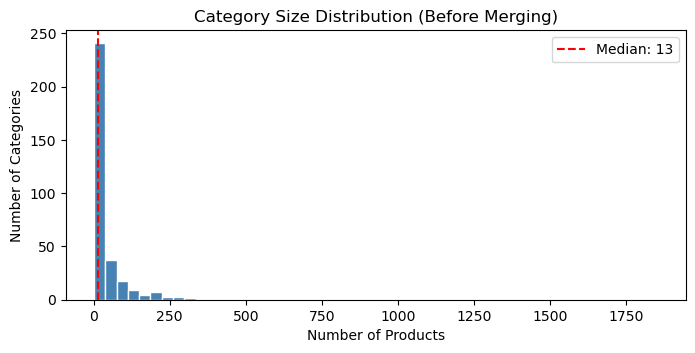

In [19]:
# Before for thesis
plt.figure(figsize=(8, 3.5))
cat2_counts = df['category_level2'].value_counts()
plt.hist(cat2_counts.values, bins=50, color='steelblue', edgecolor='white')
plt.axvline(cat2_counts.median(), color='red', linestyle='--', 
            label=f'Median: {int(cat2_counts.median())}')
plt.xlabel('Number of Products')
plt.ylabel('Number of Categories')
plt.title('Category Size Distribution (Before Merging)')
plt.legend()

In [20]:
# Check if any Level 2 maps to multiple Level 1 parents. Eg Electronics maps to Accessories, but Clothing also maps to Accessories
# We don't want these products to be mapped under the same Level 2 "Accessories" because Electronics and Clothing are very different

# For each Level 2 name, how many different Level 1 departments claim it?
hierarchy_check = (
    df.groupby('category_level2')['category_level1']
    .nunique()
    .reset_index()
    .rename(columns={'category_level1': 'num_level1_parents'})
)

inconsistent = hierarchy_check[hierarchy_check['num_level1_parents'] > 1]
print(f"Level 2 categories with multiple Level 1 parents: {len(inconsistent)}")
if not inconsistent.empty:
    print(inconsistent)

# Just to check: Flag previously imputed rows (rows that originally had no level 2)
# The idea is that products with no original Level 2 might behave differently in predicting discount
imputed_mask = df['category_level2'] == df['category_level1']
df['category_imputed'] = imputed_mask.astype(int)

print(f"\nImputed Level 2 rows: {df['category_imputed'].sum()} ({df['category_imputed'].mean()*100:.1f}%)")

# Show which Level 1 categories were used as Level 2 fill-ins
imputed_summary = (
    df[df['category_imputed'] == 1]
    .groupby('category_level1')
    .size()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={0: 'imputed_count'})
)
print(f"\nLevel 1 categories used as Level 2 fill-ins:\n{imputed_summary}")

Level 2 categories with multiple Level 1 parents: 11
                  category_level2  num_level1_parents
1                     Accessories                   3
15                     Appliances                   2
22                           Baby                   2
34          Biographies & Memoirs                   2
73         Computers & Technology                   2
168              Kitchen & Dining                   2
193           Musical Instruments                   2
194  Mystery, Thriller & Suspense                   2
251       Religion & Spirituality                   2
288             Sports & Outdoors                   2
292        Storage & Organization                   2

Imputed Level 2 rows: 24 (0.2%)

Level 1 categories used as Level 2 fill-ins:
                 category_level1  imputed_count
0   Amazon Devices & Accessories              1
1                 Amazon Renewed              1
2       Tools & Home Improvement              1
3              Sports & Outd

In [21]:
# Inspect what Level 1 parents each ambiguous Level 2 maps to
for cat in inconsistent['category_level2']:
    parents = df[df['category_level2'] == cat]['category_level1'].unique()
    count = df[df['category_level2'] == cat].shape[0]
    print(f"\n'{cat}' ({count} products) → Level 1 parents: {parents}")


'Accessories' (311 products) → Level 1 parents: ['Sports & Outdoors' 'Camera & Photo Products' 'Cell Phones & Accessories']

'Appliances' (19 products) → Level 1 parents: ['Appliances' 'Tools & Home Improvement']

'Baby' (116 products) → Level 1 parents: ['Clothing, Shoes & Jewelry' 'Baby']

'Biographies & Memoirs' (247 products) → Level 1 parents: ['Books' 'Audible Books & Originals']

'Computers & Technology' (222 products) → Level 1 parents: ['Books' 'Audible Books & Originals']

'Kitchen & Dining' (9 products) → Level 1 parents: ['Kitchen & Dining' 'Home & Kitchen']

'Musical Instruments' (6 products) → Level 1 parents: ['Musical Instruments' 'Toys & Games']

'Mystery, Thriller & Suspense' (9 products) → Level 1 parents: ['Books' 'Audible Books & Originals']

'Religion & Spirituality' (21 products) → Level 1 parents: ['Books' 'Audible Books & Originals']

'Sports & Outdoors' (13 products) → Level 1 parents: ['Sports & Outdoors' 'Audible Books & Originals']

'Storage & Organization

In [22]:
# Disambiguate by creating a composite category label for inconsistent ones
# Eg instead of "Accessories" as Level 2, now it will be a more distinct category such as "Sports & Outdoors > Accessories"
inconsistent_cats = inconsistent['category_level2'].tolist()

df['category_model'] = df.apply(
    lambda row: f"{row['category_level1']} > {row['category_level2']}" 
    if row['category_level2'] in inconsistent_cats 
    else row['category_level2'],
    axis=1
)

print(f"Final category count after disambiguation: {df['category_model'].nunique()}")

Final category count after disambiguation: 338


In [23]:
# Since category 2 is extremely right-skewed, that means the vast majority of Level 2 categories have very few products

# For any Level 2 category with < 10 products, replace its label with its Level 1 parent
# Eg "Surveillance cameras" (1 product) becomes "Electronics." "SIM cards" becomes "Electronics"
# This reduces total Level 2 category count since categories with 1-9 products can't form a meaningful cluster later
# Merge thin Level 2 categories to their Level 1 parent
cat_counts = df['category_model'].value_counts()
thin_cats = cat_counts[cat_counts < 10].index

df.loc[df['category_model'].isin(thin_cats), 'category_model'] = df['category_level1']

# Check final state
print(f"Final number of categories: {df['category_model'].nunique()}")
print(df['category_model'].value_counts())

Final number of categories: 219
category_model
Kindle eBooks                1855
Sports                        341
Exercise & Fitness            312
Replacement Parts             293
Sport Specific Clothing       278
                             ... 
Camera & Photo Products         2
Cell Phones & Accessories       1
Automotive                      1
Unique Finds                    1
Sports Collectibles             1
Name: count, Length: 219, dtype: int64


In [24]:
# There are still categories with only 1 product, which means the Level 1 parent had very few products in the dataset
# Re-check how many categories are still thin
cat_counts2 = df['category_model'].value_counts()
still_thin = cat_counts2[cat_counts2 < 10]
print(f"Still thin after merge: {len(still_thin)}")
print(still_thin)

Still thin after merge: 10
category_model
Appliances                   8
Clothing, Shoes & Jewelry    6
Health & Household           4
Sports & Outdoors            3
Movies & TV                  2
Camera & Photo Products      2
Cell Phones & Accessories    1
Automotive                   1
Unique Finds                 1
Sports Collectibles          1
Name: count, dtype: int64


In [25]:
# Loop until no thin categories remain
while True:
    cat_counts = df['category_model'].value_counts()
    thin = cat_counts[cat_counts < 10].index
    if len(thin) == 0:
        break
    df.loc[df['category_model'].isin(thin), 'category_model'] = 'Other'

print(f"Final categories: {df['category_model'].nunique()}")

Final categories: 210


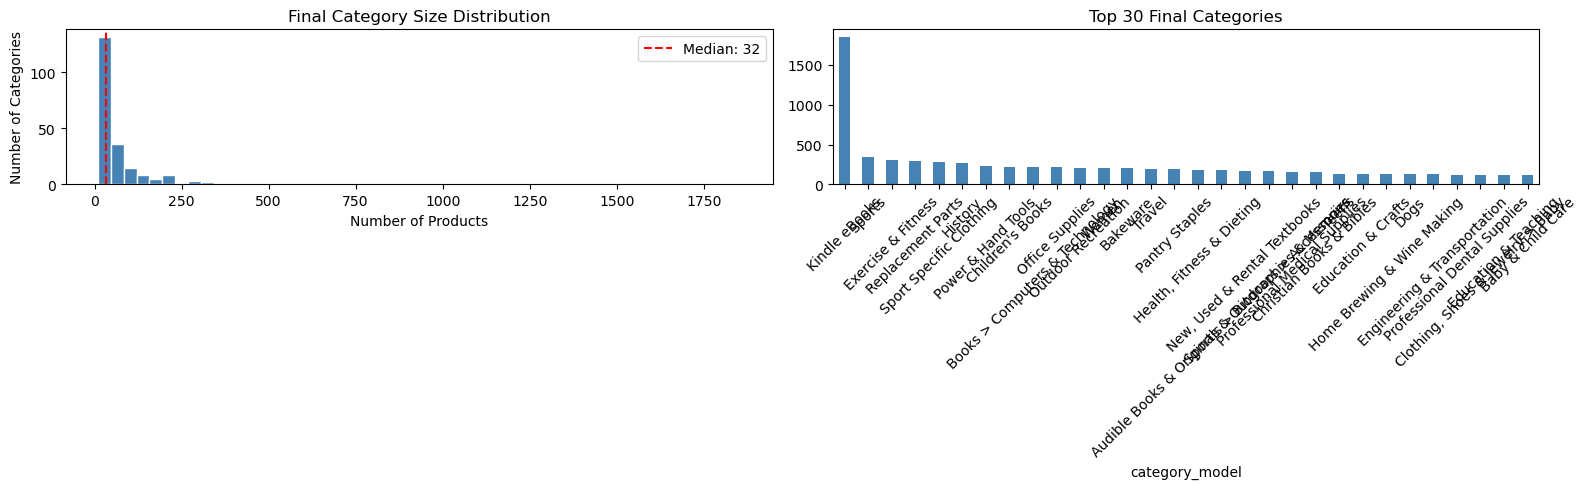

Final categories: 210
Median products per category: 32
Min products per category: 10


In [26]:
# Recheck skewness
final_counts = df['category_model'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(final_counts.values, bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(final_counts.median(), color='red', linestyle='--', 
                label=f'Median: {final_counts.median():.0f}')
axes[0].set_title('Final Category Size Distribution')
axes[0].set_xlabel('Number of Products')
axes[0].set_ylabel('Number of Categories')
axes[0].legend()

final_counts.head(30).plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Top 30 Final Categories')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(f"Final categories: {df['category_model'].nunique()}")
print(f"Median products per category: {final_counts.median():.0f}")
print(f"Min products per category: {final_counts.min()}")

Median jumped from 13 to 32, so typical category is now much better. Minimum is 10. Kindle eBooks is genuinely largest category in dataset. There is still right skewness, however this is expected and acceptable due to the natural shape of Amazon's category structure.

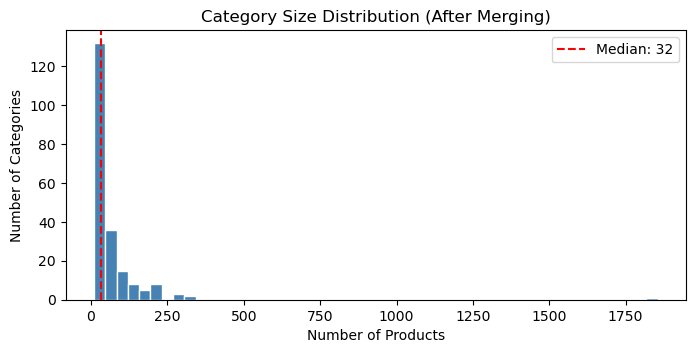

In [27]:
# Plot for thesis (for readability)
plt.figure(figsize=(8, 3.5))
final_counts = df['category_model'].value_counts()
plt.hist(final_counts.values, bins=50, color='steelblue', edgecolor='white')
plt.axvline(final_counts.median(), color='red', linestyle='--', 
            label='Median: 32')
plt.xlabel('Number of Products')
plt.ylabel('Number of Categories')
plt.title('Category Size Distribution (After Merging)')
plt.legend()
plt.savefig('figures/catdistafter.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

In [28]:
# Final category check count
print(f"Final categories: {df['category_model'].nunique()}")
print(f"Min products per category: {df['category_model'].value_counts().min()}")
print(f"Any 'Other' categories: {(df['category_model'] == 'Other').sum()}")
# Other categories is a catch-all label created by the loop for any thin categories whose Level 1 parent was also too small to meet the threshold

Final categories: 210
Min products per category: 10
Any 'Other' categories: 29


In [29]:
# Drop "Other" rows entirely since it's only 28 of them
df = df[df['category_model'] != 'Other'].copy()
print(f"Rows remaining: {len(df)}")
print(f"Final categories: {df['category_model'].nunique()}")

Rows remaining: 13715
Final categories: 209


In [30]:
# Check unique values of weight_unit column
weight_unit_count = df['weight_unit'].unique()
print(weight_unit_count)

['ounce' nan 'pound' 'gram' 'kilogram']


In [31]:
# See what units are in the data
print(df['weight_unit'].str.lower().str.strip().value_counts())

weight_unit
pound       3784
ounce       2713
gram         218
kilogram       3
Name: count, dtype: int64


In [32]:
# Fix weight units to grams since this is the most granular. Convert everything in a column "weight_grams"
UNIT_TO_GRAMS = {
    'gram': 1,
    'ounce': 28.3495,
    'pound': 453.592,
    'kilogram': 1000,
}

def convert_weight_to_grams(value, unit):
    """Convert weight to grams. Returns NaN if unit is unrecognized."""
    if pd.isna(value) or pd.isna(unit):
        return np.nan
    unit_clean = str(unit).strip().lower()
    factor = UNIT_TO_GRAMS.get(unit_clean, np.nan)
    return value * factor

df['weight_grams'] = df.apply(
    lambda row: convert_weight_to_grams(row['weight_value'], row['weight_unit']),
    axis=1
)

# Check null rate after conversion
null_rate = df['weight_grams'].isna().mean()
print(f"Null rate after conversion: {null_rate:.1%}")

Null rate after conversion: 51.0%


In [33]:
# 51% of weights are missing which is common in Amazon data because sometimes weight isn't listed
# Let's check if nulls are clustered in specific categories
null_by_category = df.groupby('category_model')['weight_grams'].apply(
    lambda x: x.isna().mean()
).sort_values(ascending=False)
print(null_by_category)

# Is discount depth different for null vs non-null weight products?
print(df.groupby(df['weight_grams'].isna())['discount_per'].describe())

category_model
DVD                               1.0
Medical Supplies & Equipment      1.0
Opera & Vocal                     1.0
Latin Music                       1.0
Politics & Social Sciences        1.0
                                 ... 
Novelty & Gag Toys                0.0
Play Vehicles                     0.0
Seasonal Décor                    0.0
Office Furniture & Accessories    0.0
Office Electronics                0.0
Name: weight_grams, Length: 209, dtype: float64
               count      mean       std  min       25%       50%       75%  \
weight_grams                                                                  
False         6718.0  0.194878  0.158954  0.0  0.069104  0.166806  0.300972   
True          6997.0  0.249183  0.275663  0.0  0.000000  0.160064  0.435736   

                   max  
weight_grams            
False         0.990000  
True          0.989385  


In [34]:
# Flag missing weight first, before any imputation
df['weight_is_missing'] = df['weight_grams'].isna().astype(int)

# Category-level median: computes median weight within each category. Eg kitchen -> 500g, electronics -> 300g
# For each null weight row, it tries to fill it with that product's category median
# This matters since weight distributions vary a lot by category
category_medians = df.groupby('category_model')['weight_grams'].median()
df['weight_grams'] = df.apply(
    lambda row: category_medians[row['category_model']] 
    if pd.isna(row['weight_grams']) and not pd.isna(category_medians[row['category_model']])
    else row['weight_grams'],
    axis=1
)

# For categories where every single row is null, it wouldn't make sense to use the category median since everything is NaN
# So global median is used, which fills those nulls with median across entire dataset
# This is here just so that the column has no nulls, not because it's informative
# That's why these were flagged as "weight_is_missing" first
global_median = df['weight_grams'].median()
df['weight_grams'] = df['weight_grams'].fillna(global_median)

In [35]:
# Log transform weights column
df['weight_grams_log'] = np.log1p(df['weight_grams'])

In [36]:
# Size column values aren't consistent and provides no value. Let's remove.
df.drop(columns=['size'], axis=1, inplace=True)
print(df.columns)

Index(['brandName', 'color', 'description', 'inStock', 'listedPrice',
       'material', 'name', 'new_path', 'nodeName', 'rating', 'reviewCount',
       'salePrice', 'weight_rawUnit', 'weight_unit', 'weight_value',
       'discount_per', 'category_level1', 'category_level2', 'category_level3',
       'category_imputed', 'category_model', 'weight_grams',
       'weight_is_missing', 'weight_grams_log'],
      dtype='object')


In [37]:
# Check unique values of color column
color_unique = df['color'].nunique()
print(color_unique)
df["color"].value_counts()

2327


color
Black              1487
White               470
Silver              174
Blue                164
Clear               114
                   ... 
Frameless Glass       1
Red & Black           1
Pack. of 100.         1
Multicolors           1
Red (Single)          1
Name: count, Length: 2327, dtype: int64

In [38]:
# See cumulative coverage of top N colors
color_counts = df['color'].value_counts()
total = len(df)

cumulative = pd.DataFrame({
    'count': color_counts,
    'pct': color_counts / total * 100,
    'cumulative_pct': (color_counts / total * 100).cumsum()
})

print(cumulative.head(20))

                 count        pct  cumulative_pct
color                                            
Black             1487  10.842144       10.842144
White              470   3.426905       14.269048
Silver             174   1.268684       15.537732
Blue               164   1.195771       16.733503
Clear              114   0.831207       17.564710
Red                 95   0.692672       18.257382
Grey                88   0.641633       18.899016
Green               87   0.634342       19.533358
black               66   0.481225       20.014583
Pink                66   0.481225       20.495808
Gray                65   0.473934       20.969741
Multicolor          58   0.422895       21.392636
Brown               58   0.422895       21.815530
Orange              51   0.371856       22.187386
Yellow              41   0.298943       22.486329
Multi               40   0.291651       22.777980
Gold                31   0.226030       23.004010
Natural             29   0.211447       23.215458


In [39]:
# The number of color categories that we want should reach 80% coverage
# Find out how many categories is 80% coverage
cutoff_80 = (cumulative['cumulative_pct'] < 80).sum() + 1
print(f"Categories needed for 80% coverage: {cutoff_80}")

Categories needed for 80% coverage: 2328


In [40]:
# Let's clean the colors to have a good number of categories
# Step 1: see how many contain recognizable color words
basic_colors = ['Black', 'White', 'Silver', 'Blue', 'Clear', 'Red', 
                'Gray', 'Grey', 'Green', 'Yellow', 'Orange', 'Purple', 
                'Brown', 'Pink', 'Gold', 'Beige', 'Multicolor', 'Multi']

def simplify_color(val):
    if pd.isna(val):
        return 'Unknown'
    val_str = str(val).lower()
    for color in basic_colors:
        if color.lower() in val_str:
            return color
    return 'Other'

df['color_grouped'] = df['color'].apply(simplify_color)
print(df['color_grouped'].value_counts())
print(f"\nUnique after grouping: {df['color_grouped'].nunique()}")

# Step 2: does the 'Other' category have real colors?
other_sample = df[df['color_grouped'] == 'Other']['color'].value_counts().head(20)
print("\nTop 'Other' values:")
print(other_sample)

color_grouped
Unknown       7442
Black         2214
Other         1403
White          723
Blue           340
Silver         216
Red            175
Grey           154
Green          150
Clear          139
Pink           123
Brown          110
Gray           110
Yellow          73
Orange          69
Multicolor      68
Multi           59
Gold            57
Purple          47
Beige           43
Name: count, dtype: int64

Unique after grouping: 20

Top 'Other' values:
color
Natural             29
Stainless Steel     28
Team Color          23
No Color            19
Khaki               18
Assorted            17
Navy                15
Original            14
Chrome              14
Transparent         13
Chicken              9
Brass                8
Original Version     8
Tan                  8
Chocolate            8
Copper               7
Strawberry           7
Cream                6
Nude                 6
Team Colors          6
Name: count, dtype: int64


In [41]:
# 7447 is a very large amount of unknown colors
# There are also some colors from the 'Other' list that we should pull out. Let's merge some colors too and clean up overall

basic_colors = [
    'Black', 'White', 'Silver', 'Blue', 'Clear', 'Red',
    'Green', 'Yellow', 'Orange', 'Purple', 'Brown', 'Pink',
    'Gold', 'Beige', 'Navy', 'Khaki', 'Chrome', 'Transparent',
    'Natural', 'Stainless Steel', 'Cream', 'Tan', 'Copper'
]

def simplify_color(val):
    if pd.isna(val):
        return 'Unknown'
    val_str = str(val).lower()
    # Handle merges explicitly first
    if 'multicolor' in val_str or 'multi' in val_str:
        return 'Multicolor'
    if 'grey' in val_str or 'gray' in val_str:
        return 'Gray'
    for color in basic_colors:
        if color.lower() in val_str:
            return color
    return 'Other'

df['color_grouped'] = df['color'].apply(simplify_color)

# Apply missingness flag similar to what was done with the Weight column
df['color_is_missing'] = (df['color_grouped'] == 'Unknown').astype(int)

print(df['color_grouped'].value_counts())
print(f"\nUnique after grouping: {df['color_grouped'].nunique()}")

color_grouped
Unknown            7442
Black              2146
Other              1206
White               698
Gray                372
Blue                330
Silver              212
Red                 157
Green               149
Multicolor          148
Clear               137
Pink                122
Brown               110
Yellow               73
Orange               69
Gold                 57
Purple               47
Beige                43
Natural              38
Stainless Steel      33
Tan                  24
Khaki                21
Navy                 21
Chrome               19
Transparent          19
Copper               11
Cream                11
Name: count, dtype: int64

Unique after grouping: 27


In [42]:
# Keep 'other' column as-is since none of these colors are frequent or meaningful enough to have their own category

# Drop color categories with fewer than ~30 rows into 'Other'
min_count = 30
rare = df['color_grouped'].value_counts()
rare_categories = rare[rare < min_count].index
df['color_grouped'] = df['color_grouped'].apply(
    lambda x: 'Other' if x in rare_categories else x
)
print(df['color_grouped'].value_counts())
print(f"Final unique: {df['color_grouped'].nunique()}")

color_grouped
Unknown            7442
Black              2146
Other              1332
White               698
Gray                372
Blue                330
Silver              212
Red                 157
Green               149
Multicolor          148
Clear               137
Pink                122
Brown               110
Yellow               73
Orange               69
Gold                 57
Purple               47
Beige                43
Natural              38
Stainless Steel      33
Name: count, dtype: int64
Final unique: 20


In [43]:
# Stainless steel in the color column is strange, but let's keep it since it could signal something about the product
# Check 'Other' colors again
other_sample = df[df['color_grouped'] == 'Other']['color'].value_counts().head(20)
print(other_sample)

color
Team Color          23
No Color            19
Khaki               18
Assorted            17
Navy                15
Chrome              14
Original            14
Transparent         13
Chicken              9
Brass                8
Tan                  8
Chocolate            8
Original Version     8
Copper               7
Strawberry           7
Team Colors          6
Cream                6
Nude                 6
Color                5
Charcoal             5
Name: count, dtype: int64


In [44]:
# Check unique values of material column
material_unique = df['material'].unique()
print(material_unique)
df["material"].value_counts()

['Polyethylene (PE)' 'Plastic' nan ... 'Paper, Cardstock' 'Sand'
 'Rubber, Rubber, Rubber or rubber composite']


material
Plastic                                                             335
Stainless Steel                                                     133
Plastic, Plastic                                                    120
100% Polyester                                                      105
Polyester                                                            92
                                                                   ... 
Polyester, Wood, Polyester, Wood, Pass: wood, Lanyard: polyester      1
Wood, Metal, Foam                                                     1
Metal, Composite, Walnut Wood                                         1
Paper, Plastic, Paper, Plastic                                        1
Rubber, Rubber, Rubber or rubber composite                            1
Name: count, Length: 2788, dtype: int64

In [45]:
# See cumulative coverage of top N materials, similar to what was done for color
material_counts = df["material"].value_counts()
total = len(df)

cumulative = pd.DataFrame({
    'count': material_counts,
    'pct': material_counts / total * 100,
    'cumulative_pct': (material_counts / total * 100).cumsum()
})

print(cumulative.head(20))

                                  count       pct  cumulative_pct
material                                                         
Plastic                             335  2.442581        2.442581
Stainless Steel                     133  0.969741        3.412322
Plastic, Plastic                    120  0.874954        4.287277
100% Polyester                      105  0.765585        5.052862
Polyester                            92  0.670798        5.723660
Aluminum                             80  0.583303        6.306963
Metal                                77  0.561429        6.868392
Paper                                65  0.473934        7.342326
Rubber                               50  0.364564        7.706890
100% Cotton                          50  0.364564        8.071455
Aluminum, Aluminum                   50  0.364564        8.436019
Silicone                             46  0.335399        8.771418
Nylon                                46  0.335399        9.106817
Alloy Stee

In [46]:
# Find how many material categories needed to reach 80% coverage
cutoff_80 = (cumulative['cumulative_pct'] < 80).sum() + 1
print(f"Categories needed for 80% coverage: {cutoff_80}")

Categories needed for 80% coverage: 2789


In [47]:
# Material column clearly has high missingness since top 18 materials only cover 11% of dataset
# check missingness
print(f"Material null rate: {df['material'].isna().mean():.1%}")

Material null rate: 60.5%


In [48]:
# Clean material column
import re

def extract_primary_material(val):
    if pd.isna(val):
        return 'Unknown'
    # Take first material before any comma
    primary = str(val).split(',')[0].strip()
    # Remove "100%" prefix
    primary = re.sub(r'^\d+%\s*', '', primary).strip()
    # Normalize duplicates like "Plastic Plastic" or "Metal Metal"
    words = primary.split()
    if len(words) == 2 and words[0].lower() == words[1].lower():
        primary = words[0]
    return primary

df['primary_material'] = df['material'].apply(extract_primary_material)

# Check coverage now
mat_counts = df['primary_material'].value_counts()
total = len(df)
cumulative = pd.DataFrame({
    'count': mat_counts,
    'pct': mat_counts / total * 100,
    'cumulative_pct': (mat_counts / total * 100).cumsum()
})
print(cumulative.head(30))
cutoff_80 = (cumulative['cumulative_pct'] < 80).sum() + 1
print(f"\nCategories needed for 80% coverage: {cutoff_80}")

                                       count        pct  cumulative_pct
primary_material                                                       
Unknown                                 8296  60.488516       60.488516
Plastic                                  646   4.710171       65.198688
Polyester                                595   4.338316       69.537003
Stainless Steel                          293   2.136347       71.673350
Cotton                                   269   1.961356       73.634707
Aluminum                                 209   1.523879       75.158585
Metal                                    197   1.436384       76.594969
Nylon                                    195   1.421801       78.016770
Rubber                                   174   1.268684       79.285454
Alloy Steel                              146   1.064528       80.349982
Paper                                    100   0.729129       81.079110
Wood                                      88   0.641633       81

In [49]:
# Apply frequency threshold similar to color column
min_count = 30
rare = df['primary_material'].value_counts()
rare_categories = rare[rare < min_count].index
df['primary_material'] = df['primary_material'].apply(
    lambda x: 'Other' if x in rare_categories else x
)

# Missingness flag
df['material_is_missing'] = (df['primary_material'] == 'Unknown').astype(int)

In [50]:
# Since Unknown takes up 60% of the dataset, let's exclude Unknown for coverage calculation
known = cumulative[cumulative.index != 'Unknown'].copy()
known['pct_of_known'] = known['count'] / known['count'].sum() * 100
known['cumulative_known'] = known['pct_of_known'].cumsum()
print(known.head(30))
cutoff_known = (known['cumulative_known'] < 80).sum() + 1
print(f"\nCategories for 80% of known materials: {cutoff_known}")

                                       count       pct  cumulative_pct  \
primary_material                                                         
Plastic                                  646  4.710171       65.198688   
Polyester                                595  4.338316       69.537003   
Stainless Steel                          293  2.136347       71.673350   
Cotton                                   269  1.961356       73.634707   
Aluminum                                 209  1.523879       75.158585   
Metal                                    197  1.436384       76.594969   
Nylon                                    195  1.421801       78.016770   
Rubber                                   174  1.268684       79.285454   
Alloy Steel                              146  1.064528       80.349982   
Paper                                    100  0.729129       81.079110   
Wood                                      88  0.641633       81.720744   
Silicone                              

In [51]:
# 106 categories is extremely fragmented. This means no single material dominates enough to build clean clusters

# Top 9 materials cover 50% of known rows. Every category after that adds less than 1%.
# So let's keep top 15 materials by count, everything else to Other
top_materials = df[df['primary_material'] != 'Unknown']['primary_material'] \
                  .value_counts().head(15).index.tolist()

df['primary_material'] = df['primary_material'].apply(
    lambda x: x if x in top_materials or x == 'Unknown' else 'Other'
)

# Merge repetitive categories first
df['primary_material'] = df['primary_material'].replace({
    'Acrylonitrile Butadiene Styrene': 'ABS',
    'Acrylonitrile Butadiene Styrene (ABS)': 'ABS'
})

print(df['primary_material'].value_counts())
print(f"\nFinal unique categories: {df['primary_material'].nunique()}")

primary_material
Unknown            8296
Other              2292
Plastic             646
Polyester           595
Stainless Steel     293
Cotton              269
Aluminum            209
Metal               197
Nylon               195
Rubber              174
Alloy Steel         146
Paper               100
Wood                 88
Silicone             86
Leather              70
Steel                59
Name: count, dtype: int64

Final unique categories: 16


In [52]:
# Make sure missingness flag is set correctly
df['material_is_missing'] = (df['primary_material'] == 'Unknown').astype(int)

# Confirm flag matches
print(df['material_is_missing'].value_counts())
print(f"Unknown count: {(df['primary_material'] == 'Unknown').sum()}")
# Both should show 8305

material_is_missing
1    8296
0    5419
Name: count, dtype: int64
Unknown count: 8296


In [53]:
# Review Count distribution
plt.figure(figsize=(10, 3.5))
df['reviewCount'].hist(bins=50)
plt.xlabel('Number of Reviews per Product')
plt.ylabel('Frequency')
plt.title('Distribution of Review Count (Before Log Transformation)')
plt.savefig('figures/reviewcountdist.png', dpi=300, bbox_inches='tight')
plt.close()

In [54]:
print(df['reviewCount'].describe())

count     13520.000000
mean       9628.827367
std       24920.381006
min           1.000000
25%         285.750000
50%        1786.000000
75%        7803.500000
max      778892.000000
Name: reviewCount, dtype: float64


In [55]:
# Review count is massively left-skewed
# Outliers would dominate if standardization is chosen
# Log transform first

# Log1p because log(0) is undefined, though min is 1 so log is fine too
df['reviewCount_log'] = np.log1p(df['reviewCount'])

In [56]:
# Review count distribution after log
plt.figure(figsize=(10, 3.5))
df['reviewCount_log'].hist(bins=50)
plt.xlabel('Log(Number of Reviews per Product)')
plt.ylabel('Frequency')
plt.title('Distribution of Review Count (After Log Transformation)')
plt.savefig('figures/reviewcountLOG.png', dpi=300, bbox_inches='tight')
plt.close()

In [57]:
# Rating
plt.figure(figsize=(10, 3.5))
df['rating'].hist(bins=30)
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.title('Distribution of Product Rating')
plt.savefig('figures/ratingdist.png', dpi=300, bbox_inches='tight')
plt.close()

In [58]:
# Check inStock values
print(df['inStock'].value_counts(dropna=False))
print(f"Null rate: {df['inStock'].isna().mean():.1%}")

inStock
TRUE     10955
NaN       2738
FALSE       22
Name: count, dtype: int64
Null rate: 20.0%


In [59]:
# Remove inStock column since it's almost entirely true. Not a lot of variance
df.drop(columns=['inStock'], axis=1, inplace=True)
print(df.columns)

Index(['brandName', 'color', 'description', 'listedPrice', 'material', 'name',
       'new_path', 'nodeName', 'rating', 'reviewCount', 'salePrice',
       'weight_rawUnit', 'weight_unit', 'weight_value', 'discount_per',
       'category_level1', 'category_level2', 'category_level3',
       'category_imputed', 'category_model', 'weight_grams',
       'weight_is_missing', 'weight_grams_log', 'color_grouped',
       'color_is_missing', 'primary_material', 'material_is_missing',
       'reviewCount_log'],
      dtype='object')


In [60]:
# Brand distribution
df['brandName'].value_counts().head(20)

brandName
.us                           864
Audible Logo                  122
Amazon Music Curated Picks     54
Amazon Basics                  44
VEVOR                          39
Dorman                         39
Rick Steves                    37
Franklin Sports                30
Brand: Generic                 26
(Author)                       23
DEWALT                         23
1                              16
ACDelco                        16
Happy Belly                    16
Fel-Pro                        12
Brand: Amazon Renewed          12
Gorilla Grip                   12
Brand: Amazon Fresh            12
Celestron                      11
Apple                          11
Name: count, dtype: int64

In [61]:
print(f"Unique brands: {df['brandName'].nunique()}")
print(f"Null rate: {df['brandName'].isna().mean():.1%}")

# How many brands appear more than 50 times?
brand_counts = df['brandName'].value_counts()
print(f"Brands with >50 products: {(brand_counts > 50).sum()}")
print(f"Brands with >20 products: {(brand_counts > 20).sum()}")

Unique brands: 8806
Null rate: 8.9%
Brands with >50 products: 3
Brands with >20 products: 11


In [62]:
# Since there are too many brands, they will be grouped into buckets
amazon_brands = ['Amazon Basics', 'Amazon Fresh', 'Amazon Renewed', 
                 'Amazon Music Curated Lists', 'Audible']

def brand_type(val):
    if pd.isna(val):
        return 'Unknown'
    val_str = str(val).strip()
    if val_str in ['.us', '1', '(Author)', '']:
        return 'Unknown'
    if 'generic' in val_str.lower():
        return 'Generic'
    if any(a.lower() in val_str.lower() for a in amazon_brands):
        return 'Amazon'
    return 'Named Brand'

df['brand_type'] = df['brandName'].apply(brand_type)
print(df['brand_type'].value_counts())

brand_type
Named Brand    11364
Unknown         2128
Amazon           192
Generic           31
Name: count, dtype: int64


These 4 categories will be used as brands instead in the new **brand_type** column.

In [63]:
# For Description column, the length of the description will be added as a feature
df['description_length'] = df['description'].fillna('').apply(lambda x: len(str(x).split()))
print(df['description_length'].describe())

plt.figure(figsize=(10, 3.5))
df['description_length'].hist(bins=50)
plt.xlabel('Description Length (words)')
plt.ylabel('Frequency')
plt.title('Distribution of Description Length (Before Log Transformation)')
plt.savefig('figures/descriptionlengthdist.png', dpi=300, bbox_inches='tight')
plt.close()

count    13715.000000
mean       196.017207
std        169.336188
min          1.000000
25%         95.000000
50%        169.000000
75%        249.000000
max       3410.000000
Name: description_length, dtype: float64


In [64]:
# Right skewed. Need to log transform

df['description_length_log'] = np.log1p(df['description_length'])

plt.figure(figsize=(10, 3.5))
df['description_length_log'].hist(bins=50)
plt.xlabel('Log(Description Length)')
plt.ylabel('Frequency')
plt.title('Distribution of Description Length (After Log Transformation)')
plt.savefig('figures/descriptionlengthLOG.png', dpi=300, bbox_inches='tight')
plt.close()

In [65]:
# For Name column, the length of the name will be added as a feature
df['name_length'] = df['name'].fillna('').apply(lambda x: len(str(x).split()))
print(df['name_length'].describe())
df['name_length'].hist()
plt.savefig('figures/namelengthdist.png', dpi=300, bbox_inches='tight')
plt.close()

plt.figure(figsize=(10, 3.5))
df['name_length'].hist(bins=50)
plt.xlabel('Name Length (words)')
plt.ylabel('Frequency')
plt.title('Distribution of Product Name Length')
plt.savefig('figures/namelengthdist.png', dpi=300, bbox_inches='tight')
plt.close()

count    13715.000000
mean        16.562742
std          8.813796
min          1.000000
25%          9.000000
50%         15.000000
75%         24.000000
max         63.000000
Name: name_length, dtype: float64


In [66]:
# Check correlations of features using the log-transformed versions
numerical_cols = ['discount_per', 'reviewCount_log', 
                  'rating', 'weight_grams_log',
                  'weight_is_missing', 'color_is_missing', 
                  'material_is_missing', 'name_length',
                  'description_length_log']

corr_matrix = df[numerical_cols].corr()
print(corr_matrix['discount_per'].sort_values(ascending=False))

discount_per              1.000000
color_is_missing          0.389703
material_is_missing       0.345928
description_length_log    0.195644
weight_is_missing         0.119192
weight_grams_log          0.084708
rating                    0.078206
reviewCount_log          -0.047104
name_length              -0.195572
Name: discount_per, dtype: float64


In [67]:
# check correlation for categorical variables

from scipy import stats

for col in ['color_grouped', 'primary_material', 'category_model', 'brand_type']:
    groups = [group['discount_per'].values 
              for _, group in df.groupby(col)]
    f_stat, p_value = stats.f_oneway(*groups)
    print(f"{col}: F={f_stat:.2f}, p={p_value:.4f}")

color_grouped: F=132.01, p=0.0000
primary_material: F=138.42, p=0.0000
category_model: F=59.90, p=0.0000
brand_type: F=73.10, p=0.0000


In [68]:
# Scale numerical columns to prepare for clustering:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Weight column
df['weight_grams_scaled'] = scaler.fit_transform(df[['weight_grams_log']])

# StandardScaler for both rating and review count after log transform
scaler_review = StandardScaler()
scaler_rating = StandardScaler()
df['reviewCount_scaled'] = scaler_review.fit_transform(df[['reviewCount_log']])
df['rating_scaled'] = scaler_rating.fit_transform(df[['rating']])

# Description length and name length columns
df['description_length_scaled'] = scaler.fit_transform(df[['description_length_log']])
df['name_length_scaled'] = scaler.fit_transform(df[['name_length']])

# Sanity check: scaled columns should have mean ~0 and std ~1
print(df['weight_grams_scaled'].describe())
print(df['reviewCount_scaled'].describe())
print(df['rating_scaled'].describe())
print(df['description_length_scaled'].describe())
print(df['name_length_scaled'].describe())

count    1.371500e+04
mean    -3.522924e-17
std      1.000036e+00
min     -4.579162e+00
25%     -4.324723e-01
50%      3.017836e-02
75%      4.748720e-01
max      4.863649e+00
Name: weight_grams_scaled, dtype: float64
count    1.352000e+04
mean    -1.009055e-16
std      1.000037e+00
min     -2.746525e+00
25%     -6.572213e-01
50%      1.126494e-01
75%      7.329285e-01
max      2.669792e+00
Name: reviewCount_scaled, dtype: float64
count    1.350700e+04
mean     1.275158e-15
std      1.000037e+00
min     -1.233019e+01
25%     -4.141970e-01
50%      2.867438e-01
75%      6.372142e-01
max      1.688626e+00
Name: rating_scaled, dtype: float64
count    1.371500e+04
mean     2.175924e-16
std      1.000036e+00
min     -4.833767e+00
25%     -4.621091e-01
50%      1.832166e-01
75%      6.187364e-01
max      3.569876e+00
Name: description_length_scaled, dtype: float64
count    1.371500e+04
mean    -1.326277e-16
std      1.000036e+00
min     -1.765789e+00
25%     -8.580885e-01
50%     -1.773128e-

## Initial Baseline Model: XGBoost Regression

In [69]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

In [71]:
# Set up numerical and categorical features
# Train model

numerical_features = [
    'weight_grams_scaled',
    'reviewCount_scaled',
    'rating_scaled',
    'description_length_scaled',
    'name_length_scaled',
    'weight_is_missing',
    'color_is_missing',
    'material_is_missing'
]

categorical_features = [
    'color_grouped',
    'primary_material',
    'brand_type',
    'category_model'
]

target = 'discount_per'

all_features = numerical_features + categorical_features

# Cast categoricals
for col in categorical_features:
    df[col] = df[col].astype('category')

X = df[all_features]
y = df[target]

# 70 / 15 / 15 split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train: (9600, 12), Val: (2057, 12), Test: (2058, 12)


In [72]:
# Train baseline model. Only use val and keep test untouched for now
baseline_model = xgb.XGBRegressor(
    enable_categorical=True,
    tree_method='hist',
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    early_stopping_rounds=50, # uses the val set to stop training before overfitting
    eval_metric='rmse'
)

baseline_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50
)

# Evaluate on val set
y_pred_val = baseline_model.predict(X_val)

rmse = np.sqrt(mean_squared_error(y_val, y_pred_val))
mae  = mean_absolute_error(y_val, y_pred_val)
r2   = r2_score(y_val, y_pred_val)

print(f"Baseline XGBoost — Val Set")
print(f"  RMSE : {rmse:.4f}")
print(f"  MAE  : {mae:.4f}")
print(f"  R²   : {r2:.4f}")

[0]	validation_0-rmse:0.21741
[50]	validation_0-rmse:0.15991
[100]	validation_0-rmse:0.16031
[104]	validation_0-rmse:0.16034
Baseline XGBoost — Val Set
  RMSE : 0.1598
  MAE  : 0.1225
  R²   : 0.4818


In [73]:
# Naive Baseline Calculation
naive_pred = np.full(len(y_test), y_train.mean())
naive_mae = mean_absolute_error(y_test, naive_pred)
naive_rmse = np.sqrt(mean_squared_error(y_test, naive_pred))
print(naive_mae, naive_rmse)

0.18343353847851396 0.2275881288163014


## K-Prototypes Clustering

In [998]:
# K-Prototypes can't handle NaN values. Double check which columns have NaNs in train set
print(X_train[numerical_features].isnull().sum())
print(X_train[categorical_features].isnull().sum())

weight_grams_scaled            0
reviewCount_scaled           133
rating_scaled                142
description_length_scaled      0
name_length_scaled             0
weight_is_missing              0
color_is_missing               0
material_is_missing            0
dtype: int64
color_grouped       0
primary_material    0
brand_type          0
category_model      0
dtype: int64


In [999]:
# Fix NaNs
from sklearn.impute import SimpleImputer

num_imputer = SimpleImputer(strategy='median')
cols_to_impute = ['reviewCount_scaled', 'rating_scaled']

X_train_kp = X_train.copy()
X_val_kp   = X_val.copy()
X_test_kp  = X_test.copy()

X_train_kp[cols_to_impute] = num_imputer.fit_transform(X_train_kp[cols_to_impute])
X_val_kp[cols_to_impute]   = num_imputer.transform(X_val_kp[cols_to_impute])
X_test_kp[cols_to_impute]  = num_imputer.transform(X_test_kp[cols_to_impute])

# Verify
print(X_train_kp[cols_to_impute].isnull().sum())
print(X_val_kp[cols_to_impute].isnull().sum())
print(X_test_kp[cols_to_impute].isnull().sum())

reviewCount_scaled    0
rating_scaled         0
dtype: int64
reviewCount_scaled    0
rating_scaled         0
dtype: int64
reviewCount_scaled    0
rating_scaled         0
dtype: int64


In [1000]:
# Recreate array so that K-prototypes will use X_train_array with imputed values
X_train_array = X_train_kp.copy()
for col in categorical_features:
    X_train_array[col] = X_train_array[col].astype(str)
X_train_array = X_train_array.to_numpy()

k=2 | cost=53629.38
k=3 | cost=48166.20
k=4 | cost=44018.12
k=5 | cost=40538.70
k=6 | cost=37900.83
k=7 | cost=35869.91
k=8 | cost=34349.58
k=9 | cost=33168.30
k=10 | cost=32172.71


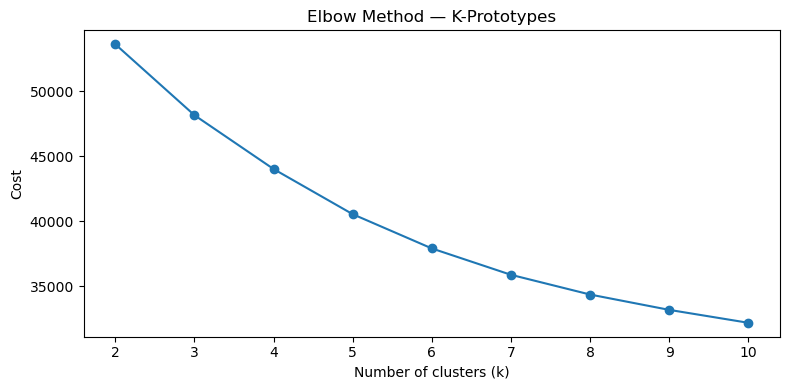

In [1001]:
# Decide k through elbow method first
from kmodes.kprototypes import KPrototypes
from sklearn.metrics import silhouette_score

cat_col_indices = [all_features.index(col) for col in categorical_features]

k_range = range(2, 11)
costs = []

for k in k_range:
    kp = KPrototypes(n_clusters=k, init='Cao', n_init=5, random_state=42)
    kp.fit(X_train_array, categorical=cat_col_indices)
    costs.append(kp.cost_)
    print(f"k={k} | cost={kp.cost_:.2f}")

plt.figure(figsize=(8, 4))
plt.plot(list(k_range), costs, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Cost')
plt.title('Elbow Method — K-Prototypes')
plt.xticks(list(k_range))
plt.tight_layout()
plt.savefig('figures/elbowmethod.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

k=2 | silhouette=0.1677
k=3 | silhouette=0.1684
k=4 | silhouette=0.1741
k=5 | silhouette=0.1695
k=6 | silhouette=0.1580
k=7 | silhouette=0.1572
k=8 | silhouette=0.1585
k=9 | silhouette=0.1578
k=10 | silhouette=0.1577


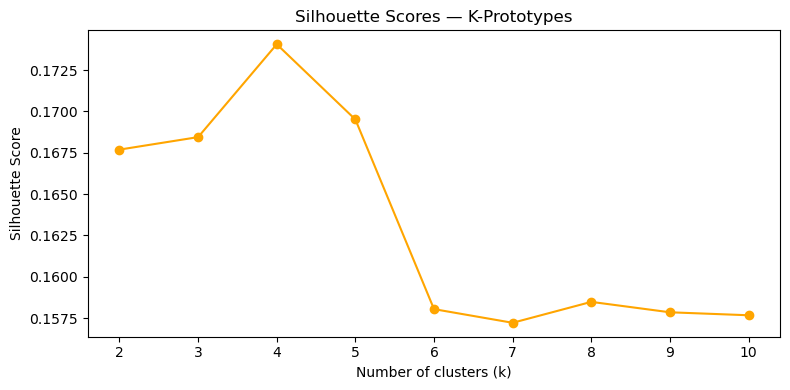

In [1002]:
# Decide k through silhouette score too and compare with elbow method
# Silhouette needs a distance matrix. we approximate using numerical features only
# This is a standard workaround since silhouette doesn't support mixed types natively

X_train_num = X_train_kp[numerical_features].to_numpy()

silhouette_scores = []

for k in k_range:
    kp = KPrototypes(n_clusters=k, init='Cao', n_init=5, random_state=42)
    labels = kp.fit_predict(X_train_array, categorical=cat_col_indices)
    score = silhouette_score(X_train_num, labels)
    silhouette_scores.append(score)
    print(f"k={k} | silhouette={score:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(list(k_range), silhouette_scores, marker='o', color='orange')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores — K-Prototypes')
plt.xticks(list(k_range))
plt.tight_layout()
plt.savefig('figures/silhouettescores.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

In [1003]:
# k = 4 is chosen given that for elbow, the steepest drop ends around k=4-5 and then curve flattens after
# for silhouette, k peaks at 4
# the scores are low in absolute terms (0.17 range), but that's expected with mixed-type data and numerical-only silhouette approximation

k_chosen = 4

kp_final = KPrototypes(n_clusters=k_chosen, init='Cao', n_init=10, random_state=42)
train_clusters = kp_final.fit_predict(X_train_array, categorical=cat_col_indices)

print(f"Cluster distribution (train):")
unique, counts = np.unique(train_clusters, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Cluster {u}: {c} samples ({c/len(train_clusters)*100:.1f}%)")

Cluster distribution (train):
  Cluster 0: 3306 samples (34.4%)
  Cluster 1: 1931 samples (20.1%)
  Cluster 2: 840 samples (8.8%)
  Cluster 3: 3523 samples (36.7%)


Distribution looks reasonably sized, so k=4 is validated.

In [1004]:
# Now the fitted K-prototypes model will be used to predict cluster labels for validation and test

def kprototypes_distances(kp_model, X_array, cat_col_indices, k):
    """
    Compute per-cluster distances for each sample.
    Returns array of shape (n_samples, k).
    """
    n_samples = X_array.shape[0]
    distances = np.zeros((n_samples, k))

    num_indices = [i for i in range(X_array.shape[1]) if i not in cat_col_indices]
    
    for cluster_idx in range(k):
        num_centroid = kp_model._enc_cluster_centroids[0][cluster_idx]
        cat_centroid = kp_model._enc_cluster_centroids[1][cluster_idx]
        
        X_num = X_array[:, num_indices].astype(float)
        X_cat = X_array[:, cat_col_indices]
        
        # Euclidean distance for numerical
        num_dist = np.sqrt(np.sum((X_num - num_centroid) ** 2, axis=1))
        
        # Hamming distance for categorical
        cat_dist = np.mean(X_cat != cat_centroid, axis=1).astype(float)
        
        # Combined using gamma (same weighting K-Prototypes uses internally)
        distances[:, cluster_idx] = num_dist + kp_model.gamma * cat_dist

    return distances
    
# Build val and test arrays
X_val_array = X_val_kp.copy()
for col in categorical_features:
    X_val_array[col] = X_val_array[col].astype(str)
X_val_array = X_val_array.to_numpy()

X_test_array = X_test_kp.copy()
for col in categorical_features:
    X_test_array[col] = X_test_array[col].astype(str)
X_test_array = X_test_array.to_numpy()

# Compute distances for all splits
train_distances = kprototypes_distances(kp_final, X_train_array, cat_col_indices, k_chosen)
val_distances   = kprototypes_distances(kp_final, X_val_array,   cat_col_indices, k_chosen)
test_distances  = kprototypes_distances(kp_final, X_test_array,  cat_col_indices, k_chosen)

In [1006]:
# Then distance columns (one per cluster) will be added as a feature to represent how far each product is from each centroid
# So the output should show original 12 features + 4 new distance columns (16 total)

dist_cols = [f'dist_cluster_{i}' for i in range(k_chosen)]

X_train_with_clusters = X_train.copy()
X_val_with_clusters   = X_val.copy()
X_test_with_clusters  = X_test.copy()

X_train_with_clusters[dist_cols] = train_distances
X_val_with_clusters[dist_cols]   = val_distances
X_test_with_clusters[dist_cols]  = test_distances

print(X_train_with_clusters.shape)
print(X_train_with_clusters[dist_cols].head())

(9600, 16)
       dist_cluster_0  dist_cluster_1  dist_cluster_2  dist_cluster_3
19563        1.773121        2.583826        3.093618        3.035273
1266         3.316818        3.445151        4.375235        1.773403
8381         2.644397        4.006342        4.047992        2.534808
16339        1.695932        2.945105        3.062111        3.305483
5494         3.417054        2.291519        3.961572        2.809640


16 columns (12 original + 4 distance columns) and the distances look sensible. Each row has one clearly smaller distance which is the assigned cluster, but the other distances give XGBoost richer information about how "between" clusters a product sits. For example row 1266 is firmly in cluster 3 (1.77) while row 8381 is more ambiguous between clusters 0 and 3 (2.64 vs 2.53).

In [1007]:
# Add cluster labels to train for profiling
X_train_profile = X_train.copy()
X_train_profile['cluster'] = train_clusters
X_train_profile['discount_per'] = y_train.values

# Summary statistics per cluster
profile = X_train_profile.groupby('cluster').agg(
    n_products=('discount_per', 'count'),
    avg_discount=('discount_per', 'mean'),
    avg_rating=('rating_scaled', 'mean'),
    avg_reviews=('reviewCount_scaled', 'mean'),
    avg_weight=('weight_grams_scaled', 'mean'),
    avg_desc_length=('description_length_scaled', 'mean')
).round(3)

print(profile)

# Categorical breakdown per cluster
for col in categorical_features:
    print(f"\n--- {col} by cluster ---")
    print(pd.crosstab(X_train_profile['cluster'], 
                      X_train_profile[col], 
                      normalize='index').round(2))

         n_products  avg_discount  avg_rating  avg_reviews  avg_weight  \
cluster                                                                  
0              3306         0.346       0.412       -0.122       0.301   
1              1931         0.145       0.217        0.007      -0.614   
2               840         0.216      -1.973       -1.195       0.147   
3              3523         0.151      -0.055        0.397      -0.005   

         avg_desc_length  
cluster                   
0                  0.468  
1                 -1.354  
2                  0.025  
3                  0.308  

--- color_grouped by cluster ---
color_grouped  Beige  Black  Blue  Brown  Clear  Gold  Gray  Green  \
cluster                                                              
0               0.00   0.03  0.01   0.00   0.00  0.00  0.00   0.00   
1               0.00   0.18  0.03   0.01   0.01  0.00  0.02   0.01   
2               0.00   0.13  0.01   0.01   0.01  0.00  0.03   0.01   
3        

In [1008]:
# Get top 3 categories per cluster
print("Top 3 categories per cluster:")
for cluster_id in sorted(X_train_profile['cluster'].unique()):
    cluster_data = X_train_profile[X_train_profile['cluster'] == cluster_id]
    top_cats = cluster_data['category_model'].value_counts(normalize=True).head(3).round(3)
    print(f"\nCluster {cluster_id} (n={len(cluster_data)}):")
    for cat, prop in top_cats.items():
        print(f"  {cat}: {prop:.1%}")

# Discount behavior more granularly
print("\nDiscount behavior by cluster:")
for cluster_id in sorted(X_train_profile['cluster'].unique()):
    cluster_data = X_train_profile[X_train_profile['cluster'] == cluster_id]
    disc = cluster_data['discount_per']
    print(f"\nCluster {cluster_id}:")
    print(f"  Mean discount        : {disc.mean():.3f}")
    print(f"  Median discount      : {disc.median():.3f}")
    print(f"  % zero discount      : {(disc == 0).mean():.1%}")
    print(f"  % high discount >40% : {(disc > 0.4).mean():.1%}")

Top 3 categories per cluster:

Cluster 0 (n=3306):
  Kindle eBooks: 28.5%
  History: 4.9%
  Books > Computers & Technology: 3.7%

Cluster 1 (n=1931):
  Kindle eBooks: 6.8%
  Replacement Parts: 5.4%
  Exercise & Fitness: 4.1%

Cluster 2 (n=840):
  Kindle eBooks: 21.1%
  Sport Specific Clothing: 3.7%
  Travel: 3.5%

Cluster 3 (n=3523):
  Sports: 3.5%
  Office Supplies: 3.1%
  Exercise & Fitness: 3.0%

Discount behavior by cluster:

Cluster 0:
  Mean discount        : 0.346
  Median discount      : 0.331
  % zero discount      : 10.7%
  % high discount >40% : 40.0%

Cluster 1:
  Mean discount        : 0.145
  Median discount      : 0.074
  % zero discount      : 44.5%
  % high discount >40% : 10.9%

Cluster 2:
  Mean discount        : 0.216
  Median discount      : 0.118
  % zero discount      : 34.0%
  % high discount >40% : 22.0%

Cluster 3:
  Mean discount        : 0.151
  Median discount      : 0.120
  % zero discount      : 33.4%
  % high discount >40% : 7.8%


In [1009]:
from scipy import stats

# ANOVA F-statistics test to see if discount depth differs significantly across clusters
X_train_profile = X_train.copy()
X_train_profile['cluster'] = train_clusters
X_train_profile['discount_per'] = y_train.values

groups = [group['discount_per'].values 
          for _, group in X_train_profile.groupby('cluster')]

f_stat, p_value = stats.f_oneway(*groups)
print(f"ANOVA F-statistic : {f_stat:.4f}")
print(f"P-value           : {p_value:.6f}")

# Mean discount depth per cluster
print("\nMean discount depth by cluster:")
print(X_train_profile.groupby('cluster')['discount_per'].mean().round(4))

ANOVA F-statistic : 607.0322
P-value           : 0.000000

Mean discount depth by cluster:
cluster
0    0.3463
1    0.1450
2    0.2158
3    0.1510
Name: discount_per, dtype: float64


## Initial Cluster-Augmented XGBoost Regression Model

In [1010]:
# XGBoost with cluster distance features
xgb_clusters = xgb.XGBRegressor(
    enable_categorical=True,
    tree_method='hist',
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    early_stopping_rounds=50,
    eval_metric='rmse'
)

xgb_clusters.fit(
    X_train_with_clusters, y_train,
    eval_set=[(X_val_with_clusters, y_val)],
    verbose=50
)

# Evaluate on val set
y_pred_val_clusters = xgb_clusters.predict(X_val_with_clusters)

rmse_c = np.sqrt(mean_squared_error(y_val, y_pred_val_clusters))
mae_c  = mean_absolute_error(y_val, y_pred_val_clusters)
r2_c   = r2_score(y_val, y_pred_val_clusters)

print(f"\nXGBoost + Clusters — Val Set")
print(f"  RMSE : {rmse_c:.4f}")
print(f"  MAE  : {mae_c:.4f}")
print(f"  R²   : {r2_c:.4f}")

# Side by side comparison
print(f"\n--- Baseline vs Cluster-Augmented (Val Set) ---")
print(f"{'Metric':<10} {'Baseline':>10} {'+ Clusters':>12} {'Delta':>10}")
print(f"{'RMSE':<10} {rmse:>10.4f} {rmse_c:>12.4f} {rmse_c - rmse:>+10.4f}")
print(f"{'MAE':<10} {mae:>10.4f} {mae_c:>12.4f} {mae_c - mae:>+10.4f}")
print(f"{'R²':<10} {r2:>10.4f} {r2_c:>12.4f} {r2_c - r2:>+10.4f}")

[0]	validation_0-rmse:0.21825
[50]	validation_0-rmse:0.16026
[100]	validation_0-rmse:0.16039
[108]	validation_0-rmse:0.16051

XGBoost + Clusters — Val Set
  RMSE : 0.1600
  MAE  : 0.1228
  R²   : 0.4802

--- Baseline vs Cluster-Augmented (Val Set) ---
Metric       Baseline   + Clusters      Delta
RMSE           0.1598       0.1600    +0.0003
MAE            0.1225       0.1228    +0.0003
R²             0.4818       0.4802    -0.0016


The differences are tiny (RMSE +0.0003, R² -0.0016) and are essentially the same performance. The cluster model also stopped much earlier (108 vs however many rounds the baseline used), suggesting the distance features aren't adding strong signal but aren't hurting either

In [1011]:
# Final test set evaluation — run once, don't tune after this
y_pred_test_base     = baseline_model.predict(X_test)
y_pred_test_clusters = xgb_clusters.predict(X_test_with_clusters)

rmse_base_test = np.sqrt(mean_squared_error(y_test, y_pred_test_base))
mae_base_test  = mean_absolute_error(y_test, y_pred_test_base)
r2_base_test   = r2_score(y_test, y_pred_test_base)

rmse_c_test = np.sqrt(mean_squared_error(y_test, y_pred_test_clusters))
mae_c_test  = mean_absolute_error(y_test, y_pred_test_clusters)
r2_c_test   = r2_score(y_test, y_pred_test_clusters)

print(f"--- Baseline vs Cluster-Augmented (Test Set) ---")
print(f"{'Metric':<10} {'Baseline':>10} {'+ Clusters':>12} {'Delta':>10}")
print(f"{'RMSE':<10} {rmse_base_test:>10.4f} {rmse_c_test:>12.4f} {rmse_c_test - rmse_base_test:>+10.4f}")
print(f"{'MAE':<10} {mae_base_test:>10.4f} {mae_c_test:>12.4f} {mae_c_test - mae_base_test:>+10.4f}")
print(f"{'R²':<10} {r2_base_test:>10.4f} {r2_c_test:>12.4f} {r2_c_test - r2_base_test:>+10.4f}")

--- Baseline vs Cluster-Augmented (Test Set) ---
Metric       Baseline   + Clusters      Delta
RMSE           0.1663       0.1659    -0.0004
MAE            0.1273       0.1268    -0.0005
R²             0.4656       0.4682    +0.0026


The inclusion of cluster-based distance features yielded a marginal but consistent improvement on the held-out test set (RMSE: -0.0004, R²: +0.0026), suggesting that competitive strategy segments capture limited but non-zero additional information for predicting discount depth.

## Initial Model Diagnostics

Are the errors random from the interim modeling pipeline (model is roughly equally wrong across all products)?
Or are errors systematic (model is consistently wrong for a specific type of product)?

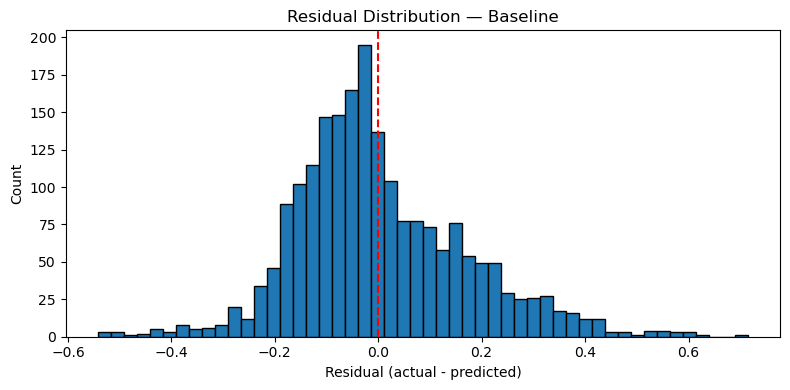

Mean residual  : 0.0022  (close to 0 = unbiased)
Std of residuals: 0.1663
Skewness       : 0.5813


In [1012]:
import matplotlib.pyplot as plt
import numpy as np

# Get predictions and residuals on test set
y_pred_test = baseline_model.predict(X_test)
residuals = y_test.values - y_pred_test

# 1. Residual distribution — are errors random or skewed?
# Eg "model consistently underpredicts discount depth for products in cluster 2" 
# If roughly centered or bell-shaped, results are unbiased
plt.figure(figsize=(8, 4))
plt.hist(residuals, bins=50, edgecolor='black')
plt.axvline(0, color='red', linestyle='--')
plt.title('Residual Distribution — Baseline')
plt.xlabel('Residual (actual - predicted)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print(f"Mean residual  : {residuals.mean():.4f}  (close to 0 = unbiased)")
print(f"Std of residuals: {residuals.std():.4f}")
print(f"Skewness       : {pd.Series(residuals).skew():.4f}")

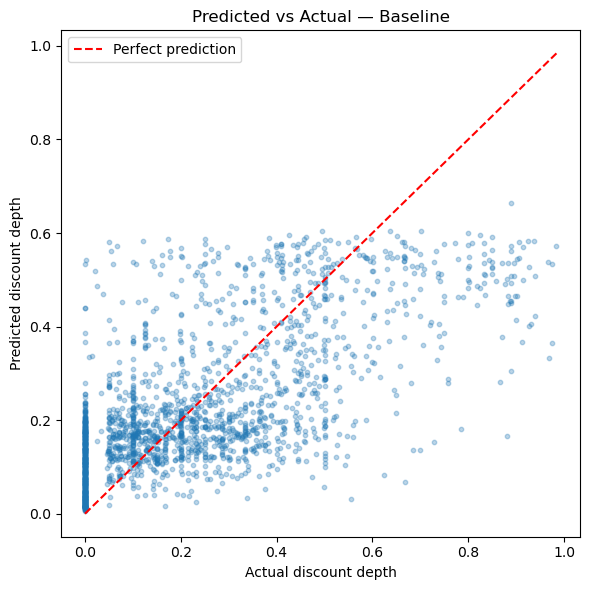

In [1013]:
# 2. Predicted vs actual — are there failure regions?
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_test, alpha=0.3, s=10)
plt.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()], 
         'r--', label='Perfect prediction')
plt.xlabel('Actual discount depth')
plt.ylabel('Predicted discount depth')
plt.title('Predicted vs Actual — Baseline')
plt.legend()
plt.tight_layout()
plt.show()

In [1014]:
# 3. Errors by cluster — are some clusters harder to predict?
X_test_profile = X_test_with_clusters.copy()
X_test_profile['actual']    = y_test.values
X_test_profile['predicted'] = xgb_clusters.predict(X_test_with_clusters)
X_test_profile['residual']  = X_test_profile['actual'] - X_test_profile['predicted']
X_test_profile['abs_error'] = X_test_profile['residual'].abs()

# Assign cluster label (closest distance)
dist_cols = [f'dist_cluster_{i}' for i in range(k_chosen)]
X_test_profile['cluster'] = X_test_profile[dist_cols].values.argmin(axis=1)

print("Mean absolute error by cluster:")
print(X_test_profile.groupby('cluster')['abs_error'].mean().round(4))

print("\nMean residual by cluster (bias check):")
print(X_test_profile.groupby('cluster')['residual'].mean().round(4))

Mean absolute error by cluster:
cluster
0    0.1564
1    0.1108
2    0.1200
3    0.1084
Name: abs_error, dtype: float64

Mean residual by cluster (bias check):
cluster
0    0.0019
1    0.0025
2    0.0041
3    0.0028
Name: residual, dtype: float64


In [1015]:
# 4. Overfitting check — compare train vs val vs test performance
y_pred_train_base = baseline_model.predict(X_train)

rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train_base))
rmse_val   = rmse        # already computed
rmse_test  = rmse_base_test  # already computed

print(f"Overfitting check — Baseline RMSE:")
print(f"  Train : {rmse_train:.4f}")
print(f"  Val   : {rmse_val:.4f}")
print(f"  Test  : {rmse_test:.4f}")
print(f"  Train-Test gap: {rmse_test - rmse_train:+.4f}")

Overfitting check — Baseline RMSE:
  Train : 0.1456
  Val   : 0.1598
  Test  : 0.1663
  Train-Test gap: +0.0207


## Refined Modeling Pipeline: Baseline and Cluster-Augmented

In [1016]:
df.columns

Index(['brandName', 'color', 'description', 'listedPrice', 'material', 'name',
       'new_path', 'nodeName', 'rating', 'reviewCount', 'salePrice',
       'weight_rawUnit', 'weight_unit', 'weight_value', 'discount_per',
       'category_level1', 'category_level2', 'category_level3',
       'category_imputed', 'category_model', 'weight_grams',
       'weight_is_missing', 'weight_grams_log', 'color_grouped',
       'color_is_missing', 'primary_material', 'material_is_missing',
       'reviewCount_log', 'brand_type', 'description_length',
       'description_length_log', 'name_length', 'weight_grams_scaled',
       'reviewCount_scaled', 'rating_scaled', 'description_length_scaled',
       'name_length_scaled'],
      dtype='object')

In [1017]:
# Add is_discounted binary flag. Make a copy of original dataset
df_model = df.copy()

df_model['is_discounted'] = (df_model['discount_per'] > 0).astype(int)

# Quick sanity check
print("is_discounted distribution:")
print(df_model['is_discounted'].value_counts(normalize=True).round(3))
print(f"\nRows with discount_per == 0: {(df_model['discount_per'] == 0).sum()}")
print(f"Rows with is_discounted == 0: {(df_model['is_discounted'] == 0).sum()}") # should match

is_discounted distribution:
is_discounted
1    0.723
0    0.277
Name: proportion, dtype: float64

Rows with discount_per == 0: 3798
Rows with is_discounted == 0: 3798


In [1018]:
# Add is_discounted to X_train / X_val / X_test

numerical_features = [
    'weight_grams_scaled',
    'reviewCount_scaled',
    'rating_scaled',
    'description_length_scaled',
    'name_length_scaled',
    'weight_is_missing',
    'color_is_missing',
    'material_is_missing',
    'is_discounted'     
]
categorical_features = [
    'color_grouped',
    'primary_material',
    'brand_type',
    'category_model'
]
target = 'discount_per'
all_features = numerical_features + categorical_features

# Cast categoricals
for col in categorical_features:
    df_model[col] = df_model[col].astype('category')

# Create quartile bins for stratification
df_model['discount_quartile'] = pd.qcut(
    df_model['discount_per'],
    q=4,
    labels=False,
    duplicates='drop'  # handles the zero-mass spike gracefully
)

X = df_model[all_features]
y = df_model[target]

# Stratified first split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=df_model['discount_quartile']  # ensures each split has all quartiles
)

# For the second split, need quartile labels for X_temp rows
temp_quartiles = df_model.loc[X_temp.index, 'discount_quartile']

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=temp_quartiles
)

# Drop the helper column from feature matrices
X_train = X_train.drop(columns=['discount_quartile'], errors='ignore')
X_val   = X_val.drop(columns=['discount_quartile'], errors='ignore')
X_test  = X_test.drop(columns=['discount_quartile'], errors='ignore')

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

# Verify stratification worked
print("\nDiscount quartile distribution across splits:")
for name, y_split in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    bins = pd.qcut(y_split, q=4, duplicates='drop')
    print(f"  {name}: {bins.value_counts(normalize=True).sort_index().round(3).to_dict()}")

Train: (9600, 13), Val: (2057, 13), Test: (2058, 13)

Discount quartile distribution across splits:
  Train: {Interval(-0.001, 0.167, closed='right'): 0.501, Interval(0.167, 0.35, closed='right'): 0.249, Interval(0.35, 0.985, closed='right'): 0.25}
  Val: {Interval(-0.001, 0.167, closed='right'): 0.5, Interval(0.167, 0.35, closed='right'): 0.25, Interval(0.35, 0.99, closed='right'): 0.249}
  Test: {Interval(-0.001, 0.167, closed='right'): 0.5, Interval(0.167, 0.35, closed='right'): 0.251, Interval(0.35, 0.966, closed='right'): 0.249}


In [1019]:
# Train baseline model again with is_discounted feature
baseline_model = xgb.XGBRegressor(
    enable_categorical=True,
    tree_method='hist',
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,           # reduced from 6
    min_child_weight=7,    # added
    subsample=0.75,        # tightened from 0.8
    colsample_bytree=0.75, # tightened from 0.8
    reg_alpha=0.1,         # added
    reg_lambda=3.0,        # added
    random_state=42,
    early_stopping_rounds=50,
    eval_metric='rmse'
)

baseline_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50
)

# Evaluate on val set
y_pred_val = baseline_model.predict(X_val)

rmse = np.sqrt(mean_squared_error(y_val, y_pred_val))
mae  = mean_absolute_error(y_val, y_pred_val)
r2   = r2_score(y_val, y_pred_val)

print(f"Baseline XGBoost — Val Set")
print(f"  RMSE : {rmse:.4f}")
print(f"  MAE  : {mae:.4f}")
print(f"  R²   : {r2:.4f}")

[0]	validation_0-rmse:0.22661
[50]	validation_0-rmse:0.15011
[100]	validation_0-rmse:0.14875
[150]	validation_0-rmse:0.14862
[181]	validation_0-rmse:0.14872
Baseline XGBoost — Val Set
  RMSE : 0.1486
  MAE  : 0.0993
  R²   : 0.5924


In [1020]:
# Check discount columns again. is_discounted should already be in X_train_with_clusters now automatically

dist_cols = [f'dist_cluster_{i}' for i in range(k_chosen)]

X_train_with_clusters = X_train.copy()
X_val_with_clusters   = X_val.copy()
X_test_with_clusters  = X_test.copy()

X_train_with_clusters[dist_cols] = train_distances
X_val_with_clusters[dist_cols]   = val_distances
X_test_with_clusters[dist_cols]  = test_distances

print(X_train_with_clusters.shape)
print(X_train_with_clusters[dist_cols].head())

(9600, 17)
       dist_cluster_0  dist_cluster_1  dist_cluster_2  dist_cluster_3
440          1.773121        2.583826        3.093618        3.035273
3659         3.316818        3.445151        4.375235        1.773403
9812         2.644397        4.006342        4.047992        2.534808
6173         1.695932        2.945105        3.062111        3.305483
13570        3.417054        2.291519        3.961572        2.809640


In [1021]:
# Train cluster-augmented XGBoost model again with new hyperparameters
xgb_clusters = xgb.XGBRegressor(
    enable_categorical=True,
    tree_method='hist',
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,           # reduced from 6
    min_child_weight=7,    # added
    subsample=0.75,        # tightened from 0.8
    colsample_bytree=0.75, # tightened from 0.8
    reg_alpha=0.1,         # added
    reg_lambda=3.0,        # added
    random_state=42,
    early_stopping_rounds=50,
    eval_metric='rmse'
)

xgb_clusters.fit(
    X_train_with_clusters, y_train,
    eval_set=[(X_val_with_clusters, y_val)],
    verbose=50
)

# Evaluate on val set
y_pred_val_clusters = xgb_clusters.predict(X_val_with_clusters)

rmse_c = np.sqrt(mean_squared_error(y_val, y_pred_val_clusters))
mae_c  = mean_absolute_error(y_val, y_pred_val_clusters)
r2_c   = r2_score(y_val, y_pred_val_clusters)

print(f"\nXGBoost + Clusters — Val Set")
print(f"  RMSE : {rmse_c:.4f}")
print(f"  MAE  : {mae_c:.4f}")
print(f"  R²   : {r2_c:.4f}")

# Side by side comparison
print(f"\n--- Baseline vs Cluster-Augmented (Val Set) ---")
print(f"{'Metric':<10} {'Baseline':>10} {'+ Clusters':>12} {'Delta':>10}")
print(f"{'RMSE':<10} {rmse:>10.4f} {rmse_c:>12.4f} {rmse_c - rmse:>+10.4f}")
print(f"{'MAE':<10} {mae:>10.4f} {mae_c:>12.4f} {mae_c - mae:>+10.4f}")
print(f"{'R²':<10} {r2:>10.4f} {r2_c:>12.4f} {r2_c - r2:>+10.4f}")

[0]	validation_0-rmse:0.22660
[50]	validation_0-rmse:0.15011
[100]	validation_0-rmse:0.14883
[150]	validation_0-rmse:0.14879
[165]	validation_0-rmse:0.14893

XGBoost + Clusters — Val Set
  RMSE : 0.1487
  MAE  : 0.0996
  R²   : 0.5916

--- Baseline vs Cluster-Augmented (Val Set) ---
Metric       Baseline   + Clusters      Delta
RMSE           0.1486       0.1487    +0.0001
MAE            0.0993       0.0996    +0.0002
R²             0.5924       0.5916    -0.0008


In [1022]:
# Final test set evaluation — run once, don't tune after this
y_pred_test_base     = baseline_model.predict(X_test)
y_pred_test_clusters = xgb_clusters.predict(X_test_with_clusters)

rmse_base_test = np.sqrt(mean_squared_error(y_test, y_pred_test_base))
mae_base_test  = mean_absolute_error(y_test, y_pred_test_base)
r2_base_test   = r2_score(y_test, y_pred_test_base)

rmse_c_test = np.sqrt(mean_squared_error(y_test, y_pred_test_clusters))
mae_c_test  = mean_absolute_error(y_test, y_pred_test_clusters)
r2_c_test   = r2_score(y_test, y_pred_test_clusters)

print(f"--- Baseline vs Cluster-Augmented (Test Set) ---")
print(f"{'Metric':<10} {'Baseline':>10} {'+ Clusters':>12} {'Delta':>10}")
print(f"{'RMSE':<10} {rmse_base_test:>10.4f} {rmse_c_test:>12.4f} {rmse_c_test - rmse_base_test:>+10.4f}")
print(f"{'MAE':<10} {mae_base_test:>10.4f} {mae_c_test:>12.4f} {mae_c_test - mae_base_test:>+10.4f}")
print(f"{'R²':<10} {r2_base_test:>10.4f} {r2_c_test:>12.4f} {r2_c_test - r2_base_test:>+10.4f}")

--- Baseline vs Cluster-Augmented (Test Set) ---
Metric       Baseline   + Clusters      Delta
RMSE           0.1390       0.1396    +0.0005
MAE            0.0945       0.0945    +0.0001
R²             0.6257       0.6229    -0.0028


## Evaluation and Error Analysis

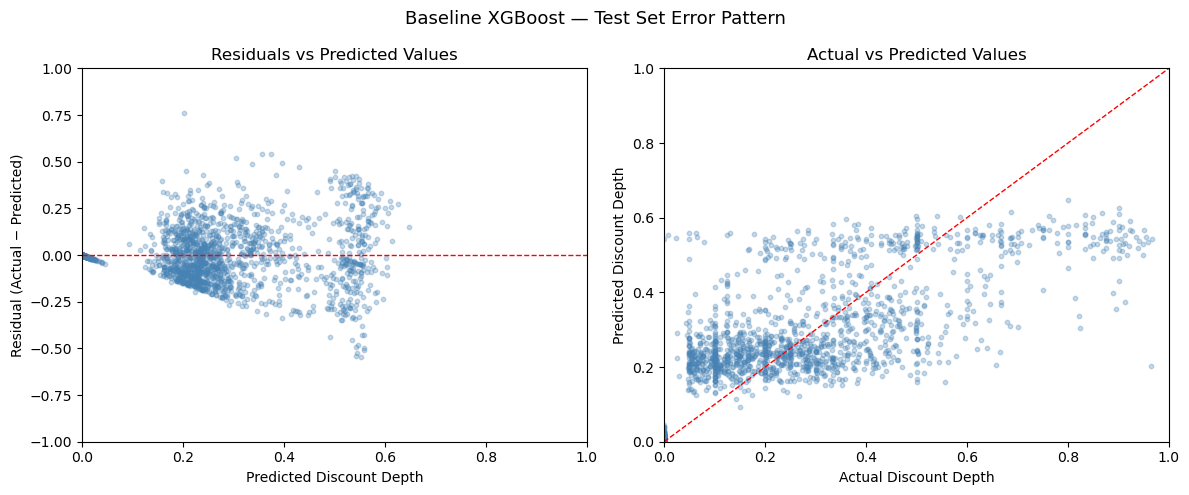

In [1025]:
# Predicted vs Actual

# Compute residuals for baseline model on test set
residuals_base = y_test - y_pred_test_base

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left plot: Residuals vs Predicted
axes[0].scatter(y_pred_test_base, residuals_base, 
                alpha=0.3, s=10, color='steelblue')
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[0].set_xlabel('Predicted Discount Depth')
axes[0].set_ylabel('Residual (Actual − Predicted)')
axes[0].set_title('Residuals vs Predicted Values')
axes[0].set_xlim(0, 1)
axes[0].set_ylim(-1, 1)

# Right plot: Actual vs Predicted
axes[1].scatter(y_test, y_pred_test_base,
                alpha=0.3, s=10, color='steelblue')
axes[1].plot([0, 1], [0, 1], color='red', linestyle='--', linewidth=1)
axes[1].set_xlabel('Actual Discount Depth')
axes[1].set_ylabel('Predicted Discount Depth')
axes[1].set_title('Actual vs Predicted Values')
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)

plt.suptitle('Baseline XGBoost — Test Set Error Pattern', fontsize=13)
plt.tight_layout()
plt.savefig('figures/error_pattern.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

In [1026]:
# Wilcoxon Test
from scipy import stats
import numpy as np

# 1. Get predictions from both models on the test set
y_pred_baseline = baseline_model.predict(X_test)
y_pred_clusters = xgb_clusters.predict(X_test_with_clusters)

# 2. Compute absolute errors per observation
# Using absolute errors: a lower value = better prediction for that observation
# Paired because both models predict the exact same test rows
ae_baseline = np.abs(y_test - y_pred_baseline)
ae_clusters = np.abs(y_test - y_pred_clusters)

# 3. Wilcoxon signed-rank test
# H0: the two models have equal prediction error distribution
# H1: the distributions differ (two-sided — we're not assuming which is better)
stat, p_value = stats.wilcoxon(ae_baseline, ae_clusters, alternative='two-sided')

print("Wilcoxon Signed-Rank Test — Baseline vs Cluster-Augmented")
print(f"  Test statistic : {stat:.4f}")
print(f"  p-value        : {p_value:.4f}")
print()
if p_value < 0.05:
    print("  Result: SIGNIFICANT — cluster features meaningfully change prediction error (p < 0.05)")
    winner = "cluster-augmented" if ae_clusters.mean() < ae_baseline.mean() else "baseline"
    print(f"  Better model: {winner}")
else:
    print("  Result: NOT SIGNIFICANT — no statistically meaningful difference between models (p >= 0.05)")
    print("  Interpretation: cluster features do not significantly improve discount depth prediction")

# 4. Supporting descriptives
print()
print("Mean Absolute Error comparison:")
print(f"  Baseline  MAE: {ae_baseline.mean():.4f}")
print(f"  Clusters  MAE: {ae_clusters.mean():.4f}")
print(f"  Difference  : {(ae_clusters.mean() - ae_baseline.mean()):.4f}")

# Effect size: matched-pairs rank-biserial correlation
# r = 0.1 small, 0.3 medium, 0.5 large
n = len(ae_baseline)
r_effect = 1 - (2 * stat) / (n * (n + 1) / 2)
print()
print(f"  Effect size (rank-biserial r): {r_effect:.4f}")
print(f"  Interpretation: {'negligible' if abs(r_effect) < 0.1 else 'small' if abs(r_effect) < 0.3 else 'medium'}")

Wilcoxon Signed-Rank Test — Baseline vs Cluster-Augmented
  Test statistic : 1052982.5000
  p-value        : 0.8131

  Result: NOT SIGNIFICANT — no statistically meaningful difference between models (p >= 0.05)
  Interpretation: cluster features do not significantly improve discount depth prediction

Mean Absolute Error comparison:
  Baseline  MAE: 0.0945
  Clusters  MAE: 0.0945
  Difference  : 0.0001

  Effect size (rank-biserial r): 0.0060
  Interpretation: negligible


In [1031]:
# Derive cluster labels for error analysis grouping only
test_clusters = np.argmin(test_distances, axis=1)

# Prep: attach errors and metadata to test set
error_df = pd.DataFrame({
    'actual':    y_test.values,
    'predicted': y_pred_baseline,
    'abs_error': ae_baseline,
    'residual':  y_test.values - y_pred_baseline,
    'cluster':   test_clusters,
    'category':  X_test_kp['category_model'].values
})

# ══════════════════════════════════════════════════════════════════════════════
# 1. MAE BY CATEGORY
# ══════════════════════════════════════════════════════════════════════════════

mae_by_cat = (
    error_df.groupby('category')['abs_error']
    .agg(MAE='mean', count='count')
    .sort_values('MAE', ascending=False)
    .reset_index()
)

# Only show categories with enough observations to be meaningful
min_obs = 10
mae_by_cat_filtered = mae_by_cat[mae_by_cat['count'] >= min_obs].copy()

print("── MAE by Category (min 10 obs, sorted by MAE) ──")
print(mae_by_cat_filtered.to_string(index=False))
print(f"\nOverall MAE:        {error_df['abs_error'].mean():.4f}")
print(f"Best category MAE:  {mae_by_cat_filtered['MAE'].min():.4f}  ({mae_by_cat_filtered.loc[mae_by_cat_filtered['MAE'].idxmin(), 'category']})")
print(f"Worst category MAE: {mae_by_cat_filtered['MAE'].max():.4f}  ({mae_by_cat_filtered.loc[mae_by_cat_filtered['MAE'].idxmax(), 'category']})")

# Plot
fig, ax = plt.subplots(figsize=(10, 25))
colors = ['#d62728' if v > error_df['abs_error'].mean() else '#1f77b4'
          for v in mae_by_cat_filtered['MAE']]
ax.barh(mae_by_cat_filtered['category'], mae_by_cat_filtered['MAE'], color=colors)
ax.axvline(error_df['abs_error'].mean(), color='black', linestyle='--',
           linewidth=1.2, label=f"Overall MAE ({error_df['abs_error'].mean():.4f})")
ax.set_xlabel('Mean Absolute Error')
ax.set_title('MAE by Product Category — Baseline Model (Full)')
ax.legend()
plt.tight_layout()
plt.savefig('figures/category_mae_full.png', dpi=300, bbox_inches='tight')
plt.close()

/var/folders/xr/84yh2vdx09j_0ch3t_dvzt0c0000gn/T/ipykernel_47957/3807465886.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  error_df.groupby('category')['abs_error']


── MAE by Category (min 10 obs, sorted by MAE) ──
                                         category      MAE  count
                           Accessories & Supplies 0.181224     10
                           Foot, Hand & Nail Care 0.150124     11
                                          Bedding 0.137553     10
                                         Fan Shop 0.132283     14
           Dairy, Eggs & Plant-Based Alternatives 0.131785     11
                  Sports & Outdoors > Accessories 0.130716     30
                    Professional Medical Supplies 0.128278     26
                                      Health Care 0.122459     10
                            Children's Audiobooks 0.121874     14
                           Cookbooks, Food & Wine 0.119750     18
                                 Business & Money 0.119636     13
                               Exercise & Fitness 0.113285     38
                                             Dogs 0.112348     21
                          

In [1032]:
# Sort by MAE
cat_mae_sorted = cat_mae_df.sort_values('MAE', ascending=False)

top10 = cat_mae_sorted.head(10)
bottom10 = cat_mae_sorted.tail(10).sort_values('MAE', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Top 10 highest MAE
axes[0].barh(top10['category'], top10['MAE'], color='steelblue')
axes[0].set_xlabel('MAE')
axes[0].set_title('10 Highest MAE Categories')
axes[0].invert_yaxis()

# Bottom 10 lowest MAE
axes[1].barh(bottom10['category'], bottom10['MAE'], color='steelblue')
axes[1].set_xlabel('MAE')
axes[1].set_title('10 Lowest MAE Categories')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('figures/category_mae.png', dpi=300, bbox_inches='tight')
plt.close()


── MAE by Discount Depth Range ──
depth_bin      MAE  count
    0–10% 0.048583    786
   10–20% 0.104631    326
   20–35% 0.081394    427
   35–50% 0.118001    269
  50–100% 0.222508    250

── Mean Residual by Discount Depth Range (bias check) ──
  Positive = model under-predicts (actual > predicted)
  Negative = model over-predicts  (actual < predicted)
depth_bin  mean_residual
    0–10%      -0.045170
   10–20%      -0.102913
   20–35%      -0.012379
   35–50%       0.063428
  50–100%       0.213113


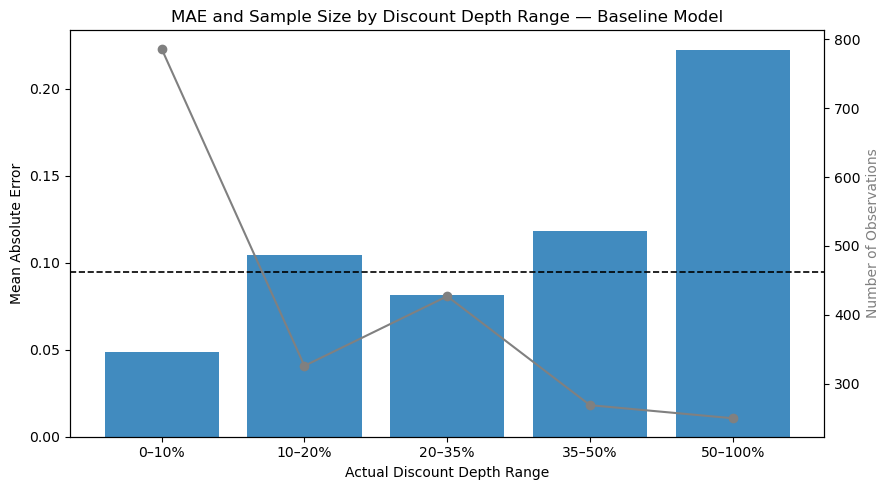

In [1042]:
# ══════════════════════════════════════════════════════════════════════════════
# 2. MAE BY DISCOUNT DEPTH RANGE
# ══════════════════════════════════════════════════════════════════════════════

# Bin actual discount depth into ranges
bins   = [0.0, 0.1, 0.2, 0.35, 0.5, 1.01]
labels = ['0–10%', '10–20%', '20–35%', '35–50%', '50–100%']

error_df['depth_bin'] = pd.cut(
    error_df['actual'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

mae_by_depth = (
    error_df.groupby('depth_bin', observed=True)['abs_error']
    .agg(MAE='mean', count='count')
    .reset_index()
)

print("\n── MAE by Discount Depth Range ──")
print(mae_by_depth.to_string(index=False))

# Bias check: are we systematically over- or under-predicting in each range?
bias_by_depth = (
    error_df.groupby('depth_bin', observed=True)['residual']
    .mean()
    .reset_index()
    .rename(columns={'residual': 'mean_residual'})
)
print("\n── Mean Residual by Discount Depth Range (bias check) ──")
print("  Positive = model under-predicts (actual > predicted)")
print("  Negative = model over-predicts  (actual < predicted)")
print(bias_by_depth.to_string(index=False))

# Plot: MAE bars + observation counts
fig, ax1 = plt.subplots(figsize=(9, 5))
ax2 = ax1.twinx()

bar_colors = ['#1f77b4'] * len(mae_by_depth)
bars = ax1.bar(mae_by_depth['depth_bin'], mae_by_depth['MAE'],
               color=bar_colors, alpha=0.85, label='MAE')
ax2.plot(mae_by_depth['depth_bin'], mae_by_depth['count'],
         color='grey', marker='o', linewidth=1.5, label='# observations')

ax1.axhline(error_df['abs_error'].mean(), color='black', linestyle='--',
            linewidth=1.2, label=f"Overall MAE ({error_df['abs_error'].mean():.4f})")
ax1.set_xlabel('Actual Discount Depth Range')
ax1.set_ylabel('Mean Absolute Error')
ax2.set_ylabel('Number of Observations', color='grey')
ax1.set_title('MAE and Sample Size by Discount Depth Range — Baseline Model')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
# ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.savefig('figures/mae_by_depth_range.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

In [1037]:
#3 MAE by cluster
Errors by cluster — are some clusters harder to predict?
X_test_profile = X_test_with_clusters.copy()
X_test_profile['actual']    = y_test.values
X_test_profile['predicted'] = xgb_clusters.predict(X_test_with_clusters)
X_test_profile['residual']  = X_test_profile['actual'] - X_test_profile['predicted']
X_test_profile['abs_error'] = X_test_profile['residual'].abs()

# Assign cluster label (closest distance)
dist_cols = [f'dist_cluster_{i}' for i in range(k_chosen)]
X_test_profile['cluster'] = X_test_profile[dist_cols].values.argmin(axis=1)

print("Mean absolute error by cluster:")
print(X_test_profile.groupby('cluster')['abs_error'].mean().round(4))

print("\nMean residual by cluster (bias check):")
print(X_test_profile.groupby('cluster')['residual'].mean().round(4))

Object `predict` not found.
Mean absolute error by cluster:
cluster
0    0.0924
1    0.0974
2    0.0906
3    0.0958
Name: abs_error, dtype: float64

Mean residual by cluster (bias check):
cluster
0   -0.0060
1    0.0009
2    0.0142
3   -0.0030
Name: residual, dtype: float64


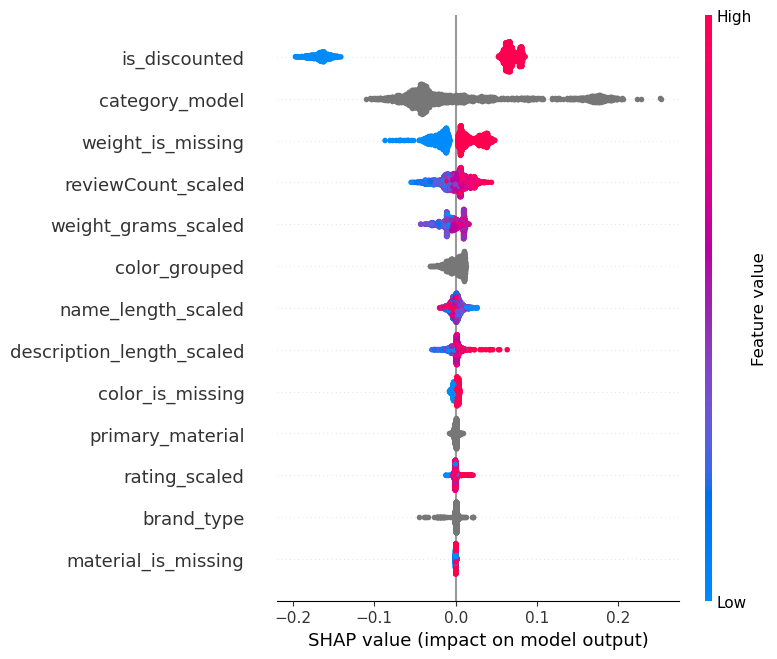

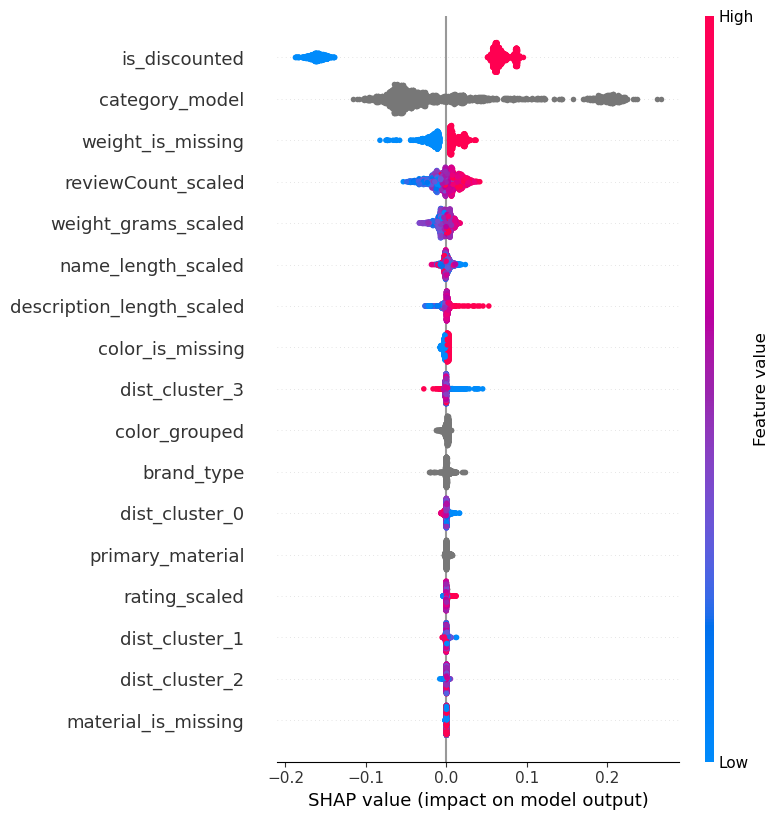

Feature importance by mean |SHAP| — cluster-augmented model:
                  feature  mean_abs_shap
            is_discounted       0.094626
           category_model       0.069353
        weight_is_missing       0.015037
       reviewCount_scaled       0.012450
      weight_grams_scaled       0.006224
       name_length_scaled       0.003147
description_length_scaled       0.002627
         color_is_missing       0.001946
           dist_cluster_3       0.001692
            color_grouped       0.001499
               brand_type       0.001475
           dist_cluster_0       0.001474
         primary_material       0.000863
            rating_scaled       0.000804
           dist_cluster_1       0.000789
           dist_cluster_2       0.000580
      material_is_missing       0.000034

Cluster distance features specifically:
       feature  mean_abs_shap  rank
dist_cluster_3       0.001692   1.0
dist_cluster_0       0.001474   2.0
dist_cluster_1       0.000789   3.0
dist_cluster_2  

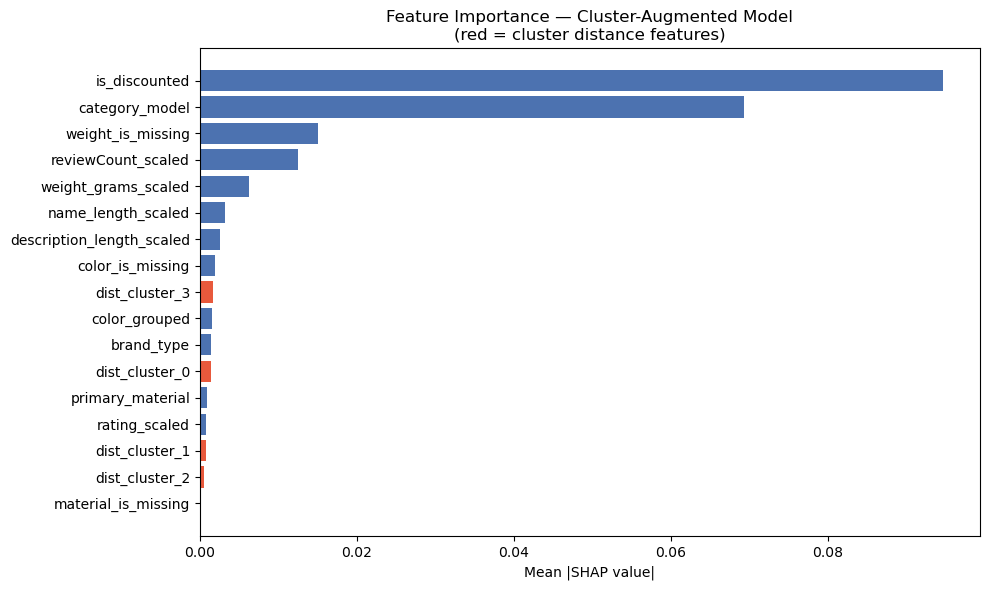


Dependence plot for: dist_cluster_3


<Figure size 1400x600 with 0 Axes>

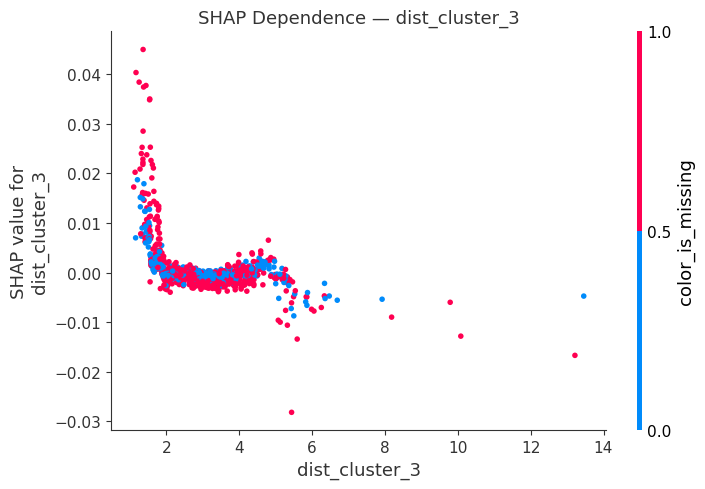

In [545]:
import shap

# ── 1. Explainers ─────────────────────────────────────────────────────────────
# TreeExplainer is exact (not approximate) for XGBoost — no sampling needed
explainer_baseline = shap.TreeExplainer(baseline_model)
explainer_clusters = shap.TreeExplainer(xgb_clusters)

# ── 2. Compute SHAP values on test set ────────────────────────────────────────
shap_values_baseline = explainer_baseline(X_test)
shap_values_clusters = explainer_clusters(X_test_with_clusters)

# ── 3. Summary plot — baseline ────────────────────────────────────────────────
plt.figure()
shap.summary_plot(
    shap_values_baseline,
    X_test,
    title="SHAP Summary — Baseline",
    show=False
)
plt.tight_layout()
plt.savefig('figures/shapsummarybaseline.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# ── 4. Summary plot — cluster-augmented ───────────────────────────────────────
plt.figure()
shap.summary_plot(
    shap_values_clusters,
    X_test_with_clusters,
    title="SHAP Summary — Cluster-Augmented",
    show=False
)
plt.tight_layout()
plt.savefig('figures/shapsummaryclusteraug.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# ── 5. Mean absolute SHAP — cluster features specifically ─────────────────────
# Extract just the cluster distance columns to see where they rank
dist_cols = [f'dist_cluster_{i}' for i in range(k_chosen)]

shap_df = pd.DataFrame(
    shap_values_clusters.values,
    columns=X_test_with_clusters.columns
)

mean_shap = shap_df.abs().mean().sort_values(ascending=False).reset_index()
mean_shap.columns = ['feature', 'mean_abs_shap']

print("Feature importance by mean |SHAP| — cluster-augmented model:")
print(mean_shap.to_string(index=False))

print("\nCluster distance features specifically:")
cluster_shap = mean_shap[mean_shap['feature'].isin(dist_cols)].copy()
cluster_shap['rank'] = cluster_shap['mean_abs_shap'].rank(ascending=False)
print(cluster_shap.to_string(index=False))

print(f"\nCluster features rank in bottom half: "
      f"{(mean_shap[mean_shap['feature'].isin(dist_cols)].index >= len(mean_shap)//2).all()}")

# ── 6. Bar plot of mean |SHAP| with cluster features highlighted ──────────────
colors = ['#E8593C' if f in dist_cols else '#4C72B0' 
          for f in mean_shap['feature']]

plt.figure(figsize=(10, 6))
plt.barh(mean_shap['feature'], mean_shap['mean_abs_shap'], color=colors)
plt.xlabel("Mean |SHAP value|")
plt.title("Feature Importance — Cluster-Augmented Model\n(red = cluster distance features)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('figures/shapbarplotmean.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# ── 7. SHAP dependence plot for most important cluster feature ─────────────────
# Shows whether discount depth varies systematically across cluster distances
best_cluster_feat = mean_shap[mean_shap['feature'].isin(dist_cols)].iloc[0]['feature']
print(f"\nDependence plot for: {best_cluster_feat}")

plt.figure()
shap.dependence_plot(
    best_cluster_feat,
    shap_values_clusters.values,
    X_test_with_clusters,
    title=f"SHAP Dependence — {best_cluster_feat}",
    show=False
)
plt.tight_layout()
plt.savefig('figures/shapdependence.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()